# Seed 00: finite versus instantaneous-formation spread analysis

Jupytext-compatible analysis for M3000, Sigma_cloud=0.1 g cm^-2,
seed 00. It compares the original epsilon_ff=0.03 simulation with an
epsilon_ff=infinity control.

The finite case uses converter.to_spicea_table() and reconstructs each
converted row's persistent NBODY6 identifiers using the exact ordering in
converter.py: current singles first, followed by current binary primaries.

The instantaneous control is built directly from the primordial population
plus every later SINGLE/BINARY entry in gradual.97 via
converter.get_primordial_binary_population(). All systems are assigned a
formation time of zero, so every star has age equal to the cluster time.

Expensive products are cached:
- SPISEA isochrones in ./iso_cache
- instantaneous master catalog
- interpolated finite and instantaneous catalogs
- per-bin and per-snapshot spread measurements

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import math
import os
import shutil
import sys
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/'
    'baraffe_pisa_ekstrom_parsec/'
)
SIMULATION_PATH = Path(
    '/standard/Tan_JC/backup_protoclusters/multiples/M3000new/'
    'sigma0p1/fiducial/sfe_ff003/00'
)

OUTPUT_DIR = Path.cwd() / 'seed00_finite_vs_infinite_outputs'
CACHE_DIR = Path.cwd() / 'analysis_cache'
ISO_CACHE_DIR = Path.cwd() / 'iso_cache'
MASTER_DIR = CACHE_DIR / 'instantaneous_master'
FINITE_DIR = CACHE_DIR / 'finite_eff003'
INFINITE_DIR = CACHE_DIR / 'infinite_eff'
METRIC_DIR = CACHE_DIR / 'metrics'

RESET_ISO_CACHE = False
RECOMPUTE_MASTER = False
RECOMPUTE_FINITE = False
RECOMPUTE_INFINITE = False
RECOMPUTE_METRICS = False
SAVE_FIGURES = True
SHOW_FIGURES = True

USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0
ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1.0e6)
ANALYSIS_TIMES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
DISPLAY_TIMES_MYR = np.array([1.0, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0, 20.0])

TEFF_BIN_EDGES_K = np.linspace(3000.0, 3600.0, 7)
N_BINS = len(TEFF_BIN_EDGES_K) - 1
MIN_STARS_PER_BIN = 8
CLIP_YOUNG_TO_GRID = True

BIN_CMAP = plt.get_cmap('viridis')
AGE_CMAP = plt.get_cmap('coolwarm')
AGE_NORM = Normalize(ISO_AGES_MYR.min(), ISO_AGES_MYR.max())
L_SUN_WATTS = 3.846e26

FILTER_OBSMODES = {
    'F070W': 'jwst,F070W',
    'F140M': 'jwst,F140M',
    'F162M': 'jwst,F162M',
    'F182M': 'jwst,F182M',
    'F200W': 'jwst,F200W',
    'F555W': 'wfc3,uvis1,f555w',
    'F814W': 'wfc3,uvis1,f814w',
}
ALL_FILTERS = list(FILTER_OBSMODES.values())

FINITE = 'finite_eff003'
INFINITE = 'infinite_eff'
CASE_LABEL = {
    FINITE: r'$\epsilon_{\rm ff}=0.03$',
    INFINITE: r'$\epsilon_{\rm ff}=\infty$',
}

## Diagram definitions

In [3]:
@dataclass(frozen=True)
class Diagram:
    key: str
    title: str
    xlabel: str
    ylabel: str
    kind: str
    blue: str | None = None
    red: str | None = None
    y_filter: str | None = None
    invert_x: bool = False
    invert_y: bool = False


DIAGRAMS = [
    Diagram('hr', r'$\log(L/L_\odot)$ vs. $T_{\rm eff}$',
            r'$T_{\rm eff}$ [K]', r'$\log(L/L_\odot)$',
            'hr', invert_x=True),
    Diagram('f070w_f200w', 'F070W - F200W vs. F200W',
            'F070W - F200W', 'F200W', 'cmd',
            'F070W', 'F200W', 'F200W', invert_y=True),
    Diagram('f182m_f200w', 'F182M - F200W vs. F200W',
            'F182M - F200W', 'F200W', 'cmd',
            'F182M', 'F200W', 'F200W', invert_y=True),
    Diagram('f140m_f162m', 'F140M - F162M vs. F162M',
            'F140M - F162M', 'F162M', 'cmd',
            'F140M', 'F162M', 'F162M', invert_y=True),
    Diagram('hst_f555w_f814w', 'HST F555W - F814W vs. F814W',
            'F555W - F814W', 'F814W', 'cmd',
            'F555W', 'F814W', 'F814W', invert_y=True),
]

## Merged evolutionary-model reader

In [4]:
class MergedBaraffePisaEkstromParsecDAT:
    def __init__(self, root_dir: Path | str, rot: bool = False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)
        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []
        self.grid_dir = self.root_dir / ('z015_rot' if rot else 'z015_norot')
        if not self.grid_dir.is_dir():
            raise FileNotFoundError(self.grid_dir)

        self.age_file_map = {}
        for path in sorted(self.grid_dir.glob('iso_*.dat')):
            try:
                log_age = float(path.stem.split('_')[1])
            except (IndexError, ValueError):
                continue
            self.age_file_map[round(log_age, 2)] = path
        if not self.age_file_map:
            raise FileNotFoundError(f'No iso_*.dat files in {self.grid_dir}')
        self.age_list = np.array(sorted(self.age_file_map), dtype=float)

    def isochrone(self, age: float = 1.0e6, metallicity: float = 0.0) -> Table:
        requested = math.log10(age)
        if requested < self.age_list[0] or requested > self.age_list[-1]:
            raise ValueError(f'logAge {requested:.4f} outside merged grid')
        idx = int(np.argmin(np.abs(self.age_list - requested)))
        selected = float(self.age_list[idx])
        path = self.age_file_map[round(selected, 2)]
        dtype = [
            ('mass', 'f8'), ('logT', 'f8'), ('logL', 'f8'),
            ('logg', 'f8'), ('logT_WR', 'f8'), ('mass_current', 'f8'),
            ('phase', 'i4'), ('model_ref', 'U32'),
        ]
        data = np.genfromtxt(path, comments='#', dtype=dtype, encoding='utf-8')
        iso = Table(np.atleast_1d(data))
        iso.add_column(Column(
            ~np.isclose(np.asarray(iso['logT'], float),
                        np.asarray(iso['logT_WR'], float),
                        rtol=0.0, atol=1.0e-8),
            name='isWR',
        ))
        iso.meta.update({
            'log_age': selected,
            'log_age_requested': requested,
            'metallicity_in': metallicity,
            'metallicity_act': 0.0,
            'source_file': str(path),
        })
        return iso

## Isochrone helpers

In [5]:
@dataclass
class IsoGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame
    filter_columns: dict[str, str]


def prepare_dirs():
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)
    for path in [OUTPUT_DIR, CACHE_DIR, ISO_CACHE_DIR, MASTER_DIR,
                 FINITE_DIR, INFINITE_DIR, METRIC_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def finish_figure(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / filename, dpi=220, bbox_inches='tight')
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def normalize_name(value):
    return ''.join(ch.lower() for ch in str(value) if ch.isalnum())


def canonical_name(value: Any) -> str:
    if isinstance(value, bytes):
        return value.decode('utf-8', errors='replace').strip()
    return str(int(value)) if isinstance(value, (int, np.integer)) else str(value).strip()


def resolve_filter_column(colnames, filter_name):
    target = normalize_name(filter_name)
    candidates = [c for c in colnames
                  if normalize_name(c).startswith('m')
                  and normalize_name(c).endswith(target)]
    instrument = 'hst' if filter_name in {'F555W', 'F814W'} else 'jwst'
    preferred = [c for c in candidates if instrument in normalize_name(c)]
    if len(preferred) == 1:
        return preferred[0]
    if len(candidates) == 1:
        return candidates[0]
    raise KeyError(f'Cannot resolve {filter_name}; candidates={candidates}; '
                   f'available={list(colnames)}')


def safe_interpolate(age_myr, mass, grid, log_ages, filters):
    try:
        with warnings.catch_warnings(), \
                contextlib.redirect_stdout(io.StringIO()), \
                contextlib.redirect_stderr(io.StringIO()):
            warnings.simplefilter('ignore')
            result = interpolator.interpolate(
                age_myr, mass, grid, log_ages, list(filters)
            )
        if result is None:
            return None
        result = np.asarray(result, float)
        if result.size != 3 + len(filters) or not np.all(np.isfinite(result)):
            return None
        return result
    except Exception:
        return None


def build_iso_grid(evo_model):
    isochrones, records = [], []
    filter_columns = None
    for age_myr, log_age in zip(ISO_AGES_MYR, ISO_LOG_AGES):
        print(f'Building/loading {age_myr:4.1f} Myr isochrone')
        try:
            iso = synthetic.IsochronePhot(
                log_age, AKS, DISTANCE_PC,
                metallicity=METALLICITY,
                evo_model=evo_model,
                atm_func=ATM_FUNC,
                red_law=RED_LAW,
                filters=ALL_FILTERS,
                iso_dir=str(ISO_CACHE_DIR),
            )
            current = {name: resolve_filter_column(iso.points.colnames, name)
                       for name in FILTER_OBSMODES}
            if filter_columns is None:
                filter_columns = current
                print('Resolved magnitude columns:')
                for name, column in current.items():
                    print(f'  {name}: {column}')
            elif current != filter_columns:
                raise RuntimeError('Magnitude columns changed across ages')
            mass = np.asarray(iso.points['mass'], float)
            isochrones.append(iso)
            records.append({
                'age_myr': age_myr, 'status': 'success',
                'n_points': len(iso.points),
                'mass_min': np.nanmin(mass), 'mass_max': np.nanmax(mass),
                'error': '',
            })
        except Exception as exc:
            isochrones.append(None)
            records.append({
                'age_myr': age_myr, 'status': 'failed', 'n_points': 0,
                'mass_min': np.nan, 'mass_max': np.nan, 'error': str(exc),
            })
            print(f'  FAILED: {exc}')
    if filter_columns is None:
        raise RuntimeError('No isochrones were built')
    return IsoGrid(ISO_AGES_MYR.copy(), ISO_LOG_AGES.copy(), isochrones,
                   pd.DataFrame(records), filter_columns)

In [6]:
prepare_dirs()
if not SIMULATION_PATH.is_dir():
    raise FileNotFoundError(SIMULATION_PATH)

evo_model = MergedBaraffePisaEkstromParsecDAT(
    UPDATED_MERGED_ROOT, rot=USE_ROTATING_MERGED
)
ISO_GRID = build_iso_grid(evo_model)
display(ISO_GRID.coverage)
failed = ISO_GRID.coverage[ISO_GRID.coverage['status'] != 'success']
if len(failed):
    raise RuntimeError('Isochrone failures:\n' +
                       failed[['age_myr', 'error']].to_string(index=False))

Building/loading  1.0 Myr isochrone
Resolved magnitude columns:
  F070W: m_jwst_F070W
  F140M: m_jwst_F140M
  F162M: m_jwst_F162M
  F182M: m_jwst_F182M
  F200W: m_jwst_F200W
  F555W: m_hst_f555w
  F814W: m_hst_f814w
Building/loading  1.5 Myr isochrone
Building/loading  2.0 Myr isochrone
Building/loading  2.5 Myr isochrone
Building/loading  3.0 Myr isochrone
Building/loading  3.5 Myr isochrone
Building/loading  4.0 Myr isochrone
Building/loading  4.5 Myr isochrone
Building/loading  5.0 Myr isochrone
Building/loading  5.5 Myr isochrone
Building/loading  6.0 Myr isochrone
Building/loading  6.5 Myr isochrone
Building/loading  7.0 Myr isochrone


Building/loading  7.5 Myr isochrone
Building/loading  8.0 Myr isochrone
Building/loading  8.5 Myr isochrone
Building/loading  9.0 Myr isochrone
Building/loading  9.5 Myr isochrone
Building/loading 10.0 Myr isochrone
Building/loading 10.5 Myr isochrone
Building/loading 11.0 Myr isochrone
Building/loading 11.5 Myr isochrone
Building/loading 12.0 Myr isochrone
Building/loading 12.5 Myr isochrone
Building/loading 13.0 Myr isochrone
Building/loading 13.5 Myr isochrone


Building/loading 14.0 Myr isochrone
Building/loading 14.5 Myr isochrone
Building/loading 15.0 Myr isochrone
Building/loading 15.5 Myr isochrone
Building/loading 16.0 Myr isochrone
Building/loading 16.5 Myr isochrone
Building/loading 17.0 Myr isochrone
Building/loading 17.5 Myr isochrone
Building/loading 18.0 Myr isochrone
Building/loading 18.5 Myr isochrone
Building/loading 19.0 Myr isochrone
Building/loading 19.5 Myr isochrone
Building/loading 20.0 Myr isochrone


,age_myr,status,n_points,mass_min,mass_max,error
0,1.0,success,1178,0.01,500.000,
1,1.5,success,1287,0.01,500.000,
2,2.0,success,1330,0.01,500.000,
3,2.5,success,2333,0.01,259.154,
4,3.0,success,1856,0.01,116.520,
5,3.5,success,1884,0.01,80.336,
6,4.0,success,1704,0.01,58.761,
7,4.5,success,1571,0.01,47.174,
8,5.0,success,1529,0.01,39.109,
9,5.5,success,1525,0.01,34.304,


## Snapshot loading with exact persistent identifiers

In [7]:
def load_cluster_table(sim_path, snapshot_time_myr):
    """Load the converter table and attach identifiers in converter order."""
    path = os.path.abspath(str(sim_path))
    if not path.endswith('/'):
        path += '/'

    snapshot = Reader.read_snapshot(path, time=float(snapshot_time_myr))
    snapshot.to_physical()
    table = converter.to_spicea_table(snapshot)

    bdict = Reader.read_binaries(
        path, snapshot=snapshot.snapshot, single_dict=True
    )
    primary_names = np.asarray(bdict['primary'], dtype=int)
    secondary_names = np.asarray(bdict['secondary'], dtype=int)
    binary_component_names = np.concatenate([primary_names, secondary_names])

    single_mask = ~np.isin(
        np.asarray(snapshot.stars.name, dtype=int), binary_component_names
    )
    singles = snapshot.stars[single_mask]
    single_names = np.asarray(singles.name, dtype=int)

    system_names = np.concatenate([single_names, primary_names])
    companion_names = np.full(len(table), -1, dtype=int)
    companion_names[len(single_names):] = secondary_names

    if len(system_names) != len(table):
        raise RuntimeError(
            'Identifier reconstruction does not match converter output: '
            f'{len(system_names)} identifiers versus {len(table)} rows.'
        )

    expected_multiple = np.concatenate([
        np.zeros(len(single_names), dtype=bool),
        np.ones(len(primary_names), dtype=bool),
    ])
    actual_multiple = np.asarray(table['isMultiple'], float) > 0
    if not np.array_equal(expected_multiple, actual_multiple):
        raise RuntimeError('Reconstructed single/binary ordering disagrees with converter output')

    table.add_column(Column(system_names, name='system_name'), index=0)
    table.add_column(Column(system_names, name='primary_name'), index=1)
    table.add_column(Column(companion_names, name='companion_name'), index=2)
    table.meta['requested_snapshot_time_myr'] = float(snapshot_time_myr)
    return table

## Instantaneous master catalog

The first 150 stellar components are primordial and are recovered from
snapshot 0. Later components are read directly from gradual.97.

We do not use converter.get_primordial_binary_population(tmin=np.inf)
because that function starts with snapshot-0 systems and then appends all
gradual.97 records, which duplicates stars that are already present at
snapshot 0.

In [8]:
MASTER_PATH = MASTER_DIR / "master_catalog.csv"

N_PRIMORDIAL_COMPONENTS = 150


def parse_gradual_formation_file(
    simulation_path: Path | str,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    """
    Parse gradual.97 into single-system and binary-system records.

    Expected formats follow converter.get_formation() and
    converter.get_primordial_binary_population():

    SINGLE ... formation_time name mass ...
    BINARY ... formation_time primary secondary m1 m2 ... ecc period semi
    """
    gradual_path = Path(simulation_path) / "gradual.97"

    if not gradual_path.is_file():
        raise FileNotFoundError(
            f"Formation file not found: {gradual_path}"
        )

    singles: list[dict[str, Any]] = []
    binaries: list[dict[str, Any]] = []

    with gradual_path.open() as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()

            if not stripped:
                continue

            fields = stripped.split()

            if len(fields) < 2 or fields[1] == "TIME":
                continue

            record_type = fields[0].upper()

            try:
                formation_time = float(fields[2])

                if record_type == "SINGLE":
                    name = int(fields[3])
                    mass = float(fields[4])

                    singles.append({
                        "system_name": name,
                        "primary_name": name,
                        "companion_name": -1,
                        "is_multiple": False,
                        "primary_initial_mass": mass,
                        "companion_initial_mass": np.nan,
                        "system_initial_mass": mass,
                        "original_birth_time_myr": formation_time,
                        "source": "gradual.97",
                        "source_line": line_number,
                    })

                elif record_type == "BINARY":
                    primary_name = int(fields[3])
                    secondary_name = int(fields[4])
                    primary_mass = float(fields[5])
                    secondary_mass = float(fields[6])

                    binaries.append({
                        "system_name": primary_name,
                        "primary_name": primary_name,
                        "companion_name": secondary_name,
                        "is_multiple": True,
                        "primary_initial_mass": primary_mass,
                        "companion_initial_mass": secondary_mass,
                        "system_initial_mass": (
                            primary_mass + secondary_mass
                        ),
                        "original_birth_time_myr": formation_time,
                        "source": "gradual.97",
                        "source_line": line_number,
                    })

            except (IndexError, TypeError, ValueError) as exc:
                raise RuntimeError(
                    f"Could not parse {gradual_path}, line "
                    f"{line_number}:\n{line.rstrip()}"
                ) from exc

    return singles, binaries


def primordial_snapshot_zero_systems(
    simulation_path: Path | str,
) -> pd.DataFrame:
    """
    Recover the primordial systems formed at t=0.

    converter.get_binary_data() returns:

    - ``single`` / ``msingle``: snapshot-0 unresolved entries;
    - ``primary`` / ``secondary`` and ``m1`` / ``m2``:
      resolved binary membership and initial component masses.

    The unresolved ``single`` array can still contain components that also
    occur in the binary arrays. We therefore construct the binary systems
    first and remove every binary-component NAME from the candidate-single
    population.
    """
    path = os.path.abspath(str(simulation_path))

    data = converter.get_binary_data(path, 0)

    candidate_single_names = np.asarray(
        data["single"],
        dtype=int,
    )
    candidate_single_masses = np.asarray(
        data["msingle"],
        dtype=float,
    )

    primary_names = np.asarray(
        data["primary"],
        dtype=int,
    )
    secondary_names = np.asarray(
        data["secondary"],
        dtype=int,
    )
    primary_masses = np.asarray(
        data["m1"],
        dtype=float,
    )
    secondary_masses = np.asarray(
        data["m2"],
        dtype=float,
    )

    if len(candidate_single_names) != len(candidate_single_masses):
        raise RuntimeError(
            "Candidate-single NAME and mass arrays have "
            "different lengths"
        )

    binary_lengths = {
        len(primary_names),
        len(secondary_names),
        len(primary_masses),
        len(secondary_masses),
    }
    if len(binary_lengths) != 1:
        raise RuntimeError(
            "Binary NAME and mass arrays have inconsistent lengths"
        )

    # Retain only binaries whose two components belong to the primordial
    # NAME range.
    primordial_binary_mask = (
        (primary_names >= 1)
        & (primary_names <= N_PRIMORDIAL_COMPONENTS)
        & (secondary_names >= 1)
        & (secondary_names <= N_PRIMORDIAL_COMPONENTS)
    )

    primordial_primary_names = primary_names[
        primordial_binary_mask
    ]
    primordial_secondary_names = secondary_names[
        primordial_binary_mask
    ]
    primordial_primary_masses = primary_masses[
        primordial_binary_mask
    ]
    primordial_secondary_masses = secondary_masses[
        primordial_binary_mask
    ]

    # Components represented by a binary system must not also be entered
    # as standalone systems.
    primordial_binary_component_names = np.concatenate([
        primordial_primary_names,
        primordial_secondary_names,
    ])

    primordial_single_mask = (
        (candidate_single_names >= 1)
        & (
            candidate_single_names
            <= N_PRIMORDIAL_COMPONENTS
        )
        & ~np.isin(
            candidate_single_names,
            primordial_binary_component_names,
        )
    )

    true_single_names = candidate_single_names[
        primordial_single_mask
    ]
    true_single_masses = candidate_single_masses[
        primordial_single_mask
    ]

    singles = pd.DataFrame({
        "system_name": true_single_names,
        "primary_name": true_single_names,
        "companion_name": -1,
        "is_multiple": False,
        "primary_initial_mass": true_single_masses,
        "companion_initial_mass": np.nan,
        "system_initial_mass": true_single_masses,
        "original_birth_time_myr": 0.0,
        "source": "snapshot_0_primordial_single",
        "source_line": -1,
    })

    binaries = pd.DataFrame({
        "system_name": primordial_primary_names,
        "primary_name": primordial_primary_names,
        "companion_name": primordial_secondary_names,
        "is_multiple": True,
        "primary_initial_mass": primordial_primary_masses,
        "companion_initial_mass": (
            primordial_secondary_masses
        ),
        "system_initial_mass": (
            primordial_primary_masses
            + primordial_secondary_masses
        ),
        "original_birth_time_myr": 0.0,
        "source": "snapshot_0_primordial_binary",
        "source_line": -1,
    })

    primordial = pd.concat(
        [singles, binaries],
        ignore_index=True,
    )

    # Validate this portion before combining it with gradual.97.
    component_names = np.concatenate([
        primordial["primary_name"].to_numpy(dtype=int),
        primordial.loc[
            primordial["is_multiple"].astype(bool),
            "companion_name",
        ].to_numpy(dtype=int),
    ])

    duplicate_mask = pd.Series(
        component_names
    ).duplicated(keep=False).to_numpy()

    if duplicate_mask.any():
        duplicates = np.unique(
            component_names[duplicate_mask]
        )
        raise RuntimeError(
            "Duplicate primordial component NAME values remain "
            f"after removing binary components from singles: "
            f"{duplicates[:50]}"
        )

    recovered_names = set(component_names.tolist())
    expected_names = set(
        range(1, N_PRIMORDIAL_COMPONENTS + 1)
    )

    missing_names = sorted(
        expected_names - recovered_names
    )
    unexpected_names = sorted(
        recovered_names - expected_names
    )

    print("Primordial reconstruction:")
    print(f"  true single systems: {len(singles)}")
    print(f"  binary systems:      {len(binaries)}")
    print(f"  stellar components:  {len(component_names)}")
    print(f"  missing NAME values: {missing_names}")
    print(f"  unexpected values:   {unexpected_names}")

    if missing_names:
        raise RuntimeError(
            "The primordial reconstruction did not recover all "
            f"NAME values 1--{N_PRIMORDIAL_COMPONENTS}. "
            f"Missing: {missing_names}"
        )

    if unexpected_names:
        raise RuntimeError(
            "The primordial reconstruction contains NAME values "
            "outside the expected range: "
            f"{unexpected_names}"
        )

    return primordial


def validate_master_catalog(master: pd.DataFrame) -> None:
    required = {
        "system_name",
        "primary_name",
        "companion_name",
        "is_multiple",
        "primary_initial_mass",
        "companion_initial_mass",
        "system_initial_mass",
    }
    missing = required.difference(master.columns)

    if missing:
        raise RuntimeError(
            f"Master catalog is missing columns: {sorted(missing)}"
        )

    primary_names = master["primary_name"].to_numpy(dtype=int)
    companion_names = master.loc[
        master["is_multiple"].astype(bool),
        "companion_name",
    ].to_numpy(dtype=int)

    component_names = np.concatenate([
        primary_names,
        companion_names,
    ])

    duplicate_mask = pd.Series(
        component_names
    ).duplicated(keep=False).to_numpy()

    if duplicate_mask.any():
        duplicate_names = np.unique(
            component_names[duplicate_mask]
        )

        offending = master[
            master["primary_name"].isin(duplicate_names)
            | master["companion_name"].isin(duplicate_names)
        ].sort_values(
            ["system_name", "primary_name"]
        )

        raise RuntimeError(
            "Duplicate component NAME values remain in the "
            "instantaneous master catalog.\n"
            f"Duplicate values: {duplicate_names[:50]}\n"
            "Offending systems:\n"
            + offending.head(50).to_string(index=False)
        )

    if master["system_name"].duplicated().any():
        duplicates = master[
            master["system_name"].duplicated(keep=False)
        ]
        raise RuntimeError(
            "Duplicate system identifiers remain:\n"
            + duplicates.head(50).to_string(index=False)
        )

    if not np.all(
        np.isfinite(master["primary_initial_mass"])
    ):
        raise RuntimeError(
            "Master catalog contains non-finite primary masses"
        )

    if np.any(master["primary_initial_mass"] <= 0):
        raise RuntimeError(
            "Master catalog contains nonpositive primary masses"
        )

    binary_mask = master["is_multiple"].astype(bool)

    if not np.all(
        np.isfinite(
            master.loc[
                binary_mask,
                "companion_initial_mass",
            ]
        )
    ):
        raise RuntimeError(
            "One or more binary systems have non-finite "
            "companion masses"
        )

    if np.any(
        master.loc[
            binary_mask,
            "companion_initial_mass",
        ] <= 0
    ):
        raise RuntimeError(
            "One or more binary systems have nonpositive "
            "companion masses"
        )


def build_instantaneous_master_catalog(
    simulation_path: Path | str,
) -> pd.DataFrame:
    primordial = primordial_snapshot_zero_systems(
        simulation_path
    )

    gradual_singles, gradual_binaries = (
        parse_gradual_formation_file(simulation_path)
    )

    gradual = pd.DataFrame(
        gradual_singles + gradual_binaries
    )

    if gradual.empty:
        raise RuntimeError(
            "No stellar formation records were read from gradual.97"
        )

    # By the simulation convention used in converter.to_spicea_table(),
    # NAME values 1--150 are primordial. Remove any accidental primordial
    # records from gradual.97 rather than appending them a second time.
    gradual_component_is_primordial = (
        gradual["primary_name"].between(
            1,
            N_PRIMORDIAL_COMPONENTS,
        )
        | (
            gradual["is_multiple"].astype(bool)
            & gradual["companion_name"].between(
                1,
                N_PRIMORDIAL_COMPONENTS,
            )
        )
    )

    if gradual_component_is_primordial.any():
        removed = gradual[
            gradual_component_is_primordial
        ]

        print(
            "Removing gradual.97 records that overlap the "
            f"primordial NAME range: {len(removed)} systems"
        )
        display(removed.head(20))

        gradual = gradual[
            ~gradual_component_is_primordial
        ].copy()

    master = pd.concat(
        [primordial, gradual],
        ignore_index=True,
    )

    master["instantaneous_birth_time_myr"] = 0.0

    master = master.sort_values(
        [
            "original_birth_time_myr",
            "is_multiple",
            "system_name",
        ],
        kind="stable",
    ).reset_index(drop=True)

    validate_master_catalog(master)

    return master


if MASTER_PATH.exists() and not RECOMPUTE_MASTER:
    print("Loading cached instantaneous master catalog")
    df_master = pd.read_csv(MASTER_PATH)

    # CSV loading can turn booleans into strings in some cases.
    if df_master["is_multiple"].dtype == object:
        df_master["is_multiple"] = (
            df_master["is_multiple"]
            .astype(str)
            .str.lower()
            .map({"true": True, "false": False})
        )

    validate_master_catalog(df_master)

else:
    print(
        "Building instantaneous master catalog from "
        "primordial snapshot-0 systems and gradual.97"
    )

    df_master = build_instantaneous_master_catalog(
        SIMULATION_PATH
    )
    df_master.to_csv(MASTER_PATH, index=False)


binary_mask = df_master["is_multiple"].astype(bool)

print(f"Master catalog: {len(df_master)} systems")
print("Singles:", int((~binary_mask).sum()))
print("Binaries:", int(binary_mask.sum()))
print(
    "Components:",
    int(len(df_master) + binary_mask.sum()),
)
print(
    "Initial mass:",
    df_master["system_initial_mass"].sum(),
    "Msun",
)
print(
    "NAME range:",
    int(
        min(
            df_master["primary_name"].min(),
            df_master.loc[
                binary_mask,
                "companion_name",
            ].min(),
        )
    ),
    "to",
    int(
        max(
            df_master["primary_name"].max(),
            df_master.loc[
                binary_mask,
                "companion_name",
            ].max(),
        )
    ),
)

display(df_master.head())
display(
    df_master.sort_values(
        "system_initial_mass",
        ascending=False,
    ).head(20)
)

Building instantaneous master catalog from primordial snapshot-0 systems and gradual.97


Primordial reconstruction:
  true single systems: 54
  binary systems:      48
  stellar components:  150
  missing NAME values: []
  unexpected values:   []
Master catalog: 2822 systems
Singles: 1411
Binaries: 1411
Components: 4233
Initial mass: 1498.4820008474835 Msun
NAME range: 1 to 4233


,system_name,primary_name,companion_name,is_multiple,primary_initial_mass,companion_initial_mass,system_initial_mass,original_birth_time_myr,source,source_line,instantaneous_birth_time_myr
0,97,97,-1,False,0.064228,NaN,0.064228,0.0,snapshot_0_primordial_single,-1,0.0
1,98,98,-1,False,0.076967,NaN,0.076967,0.0,snapshot_0_primordial_single,-1,0.0
2,99,99,-1,False,0.632793,NaN,0.632793,0.0,snapshot_0_primordial_single,-1,0.0
3,100,100,-1,False,0.101508,NaN,0.101508,0.0,snapshot_0_primordial_single,-1,0.0
4,101,101,-1,False,0.749662,NaN,0.749662,0.0,snapshot_0_primordial_single,-1,0.0


,system_name,primary_name,companion_name,is_multiple,primary_initial_mass,companion_initial_mass,system_initial_mass,original_birth_time_myr,source,source_line,instantaneous_birth_time_myr
2044,3057,3057,3058,True,18.006587,12.216717,30.223304,4.449110,gradual.97,1945,0.0
1408,2102,2102,-1,False,25.388293,NaN,25.388293,2.951526,gradual.97,1309,0.0
327,481,481,-1,False,20.581238,NaN,20.581238,0.528781,gradual.97,228,0.0
2299,3438,3438,3439,True,14.391114,5.054290,19.445404,5.044870,gradual.97,2200,0.0
2603,3900,3900,-1,False,17.906645,NaN,17.906645,5.838929,gradual.97,2504,0.0
407,602,602,603,True,12.818908,4.954929,17.773837,0.718340,gradual.97,308,0.0
1338,1989,1989,1990,True,9.065269,8.067213,17.132482,2.714470,gradual.97,1239,0.0
1471,2196,2196,2197,True,12.639112,4.357876,16.996988,3.153281,gradual.97,1372,0.0
812,1220,1220,1221,True,9.423008,6.047099,15.470107,1.704487,gradual.97,713,0.0
748,1120,1120,1121,True,7.361091,6.946276,14.307367,1.527819,gradual.97,649,0.0


## Interpolation cache

In [9]:
FILTER_NAMES = list(FILTER_OBSMODES)
FILTER_KEYS = [ISO_GRID.filter_columns[name] for name in FILTER_NAMES]
CATALOG_COLUMNS = [
    'case', 'system_index', 'system_name', 'primary_name', 'companion_name',
    'is_multiple', 'mass', 'age_myr', 'age_used_myr',
    'age_clipped_to_grid', 'teff', 'luminosity_watts',
    'log_luminosity_lsun', 'logg',
    *[f'mag_{name}' for name in FILTER_NAMES],
]


def cache_paths(case, time_myr):
    directory = FINITE_DIR if case == FINITE else INFINITE_DIR
    return (directory / f'catalog_t{time_myr:04.1f}myr.csv',
            directory / f'accounting_t{time_myr:04.1f}myr.json')


def interpolate_arrays(case, system_names, primary_names, companion_names,
                       is_multiple, masses, ages):
    rows = []
    counters = {
        'nonfinite_mass': 0, 'nonfinite_age': 0,
        'younger_than_grid': 0, 'older_than_grid': 0,
        'interpolation_failed': 0, 'nonpositive_luminosity': 0,
        'retained': 0,
    }
    min_age = float(ISO_GRID.ages_myr.min())
    max_age = float(ISO_GRID.ages_myr.max())

    for idx, values in enumerate(zip(
        system_names, primary_names, companion_names,
        is_multiple, masses, ages,
    )):
        system_name, primary_name, companion_name, multiple, mass, age = values
        if not np.isfinite(mass):
            counters['nonfinite_mass'] += 1
            continue
        if not np.isfinite(age):
            counters['nonfinite_age'] += 1
            continue

        used_age = float(age)
        clipped = False
        if used_age < min_age:
            counters['younger_than_grid'] += 1
            if not CLIP_YOUNG_TO_GRID:
                continue
            used_age, clipped = min_age, True
        if used_age > max_age:
            counters['older_than_grid'] += 1
            continue

        result = safe_interpolate(
            used_age, float(mass), ISO_GRID.isochrones,
            ISO_GRID.log_ages, FILTER_KEYS,
        )
        if result is None:
            counters['interpolation_failed'] += 1
            continue

        luminosity, teff, logg = map(float, result[:3])
        if luminosity <= 0:
            counters['nonpositive_luminosity'] += 1
            continue

        row = {
            'case': case,
            'system_index': idx,
            'system_name': canonical_name(system_name),
            'primary_name': canonical_name(primary_name),
            'companion_name': canonical_name(companion_name),
            'is_multiple': bool(multiple),
            'mass': float(mass),
            'age_myr': float(age),
            'age_used_myr': used_age,
            'age_clipped_to_grid': clipped,
            'teff': teff,
            'luminosity_watts': luminosity,
            'log_luminosity_lsun': np.log10(luminosity / L_SUN_WATTS),
            'logg': logg,
        }
        row.update({f'mag_{name}': float(value)
                    for name, value in zip(FILTER_NAMES, result[3:])})
        rows.append(row)
        counters['retained'] += 1

    df = pd.DataFrame(rows, columns=CATALOG_COLUMNS)
    df.attrs['counters'] = counters
    return df


def finite_catalog(time_myr):
    table = load_cluster_table(SIMULATION_PATH, time_myr)
    df = interpolate_arrays(
        FINITE,
        np.asarray(table['system_name'], int),
        np.asarray(table['primary_name'], int),
        np.asarray(table['companion_name'], int),
        np.asarray(table['isMultiple'], float) > 0,
        np.asarray(table['mass'], float),
        np.asarray(table['age'], float),
    )
    return df, len(table)


def infinite_catalog(time_myr):
    df = interpolate_arrays(
        INFINITE,
        df_master['system_name'].to_numpy(int),
        df_master['primary_name'].to_numpy(int),
        df_master['companion_name'].to_numpy(int),
        df_master['is_multiple'].astype(bool).to_numpy(),
        df_master['primary_initial_mass'].to_numpy(float),
        np.full(len(df_master), float(time_myr)),
    )
    return df, len(df_master)


def save_catalog(df, case, time_myr, n_input):
    csv_path, json_path = cache_paths(case, time_myr)
    df.to_csv(csv_path, index=False)
    accounting = {
        'case': case, 'snapshot_time_myr': float(time_myr),
        'n_input_systems': int(n_input),
        'n_retained_systems': int(len(df)),
        **df.attrs['counters'],
    }
    json_path.write_text(json.dumps(accounting, indent=2))
    return accounting


def load_catalog(case, time_myr):
    csv_path, json_path = cache_paths(case, time_myr)
    return pd.read_csv(csv_path), json.loads(json_path.read_text())


catalogs = {}
accounting_rows = []
for time_myr in ANALYSIS_TIMES_MYR:
    time_myr = float(time_myr)
    print('=' * 72)
    print(f'Cluster time: {time_myr:.1f} Myr')
    for case, builder, recompute in [
        (FINITE, finite_catalog, RECOMPUTE_FINITE),
        (INFINITE, infinite_catalog, RECOMPUTE_INFINITE),
    ]:
        csv_path, json_path = cache_paths(case, time_myr)
        if csv_path.exists() and json_path.exists() and not recompute:
            df, accounting = load_catalog(case, time_myr)
            print(f'  loaded cached {case}')
        else:
            try:
                df, n_input = builder(time_myr)
                accounting = save_catalog(df, case, time_myr, n_input)
            except Exception as exc:
                print(f'  {case} failed: {exc}')
                df = pd.DataFrame(columns=CATALOG_COLUMNS)
                accounting = {
                    'case': case, 'snapshot_time_myr': time_myr,
                    'status': 'failed', 'error': str(exc),
                    'n_input_systems': 0, 'n_retained_systems': 0,
                }
        catalogs[(case, time_myr)] = df
        accounting_rows.append({
            **accounting,
            'status': accounting.get('status', 'success'),
            'error': accounting.get('error', ''),
        })
        print(f"  {case}: retained {len(df)}/{accounting.get('n_input_systems', 0)}")


df_accounting = pd.DataFrame(accounting_rows)
df_accounting.to_csv(
    OUTPUT_DIR / 'finite_and_infinite_interpolation_accounting.csv', index=False
)
display(df_accounting)

Cluster time: 1.0 Myr


  finite_eff003: retained 543/543


  infinite_eff: retained 2822/2822
Cluster time: 1.5 Myr


  finite_eff003: retained 756/756


  infinite_eff: retained 2822/2822
Cluster time: 2.0 Myr


...

  finite_eff003: retained 2931/2939


  infinite_eff: retained 2812/2822
Cluster time: 20.0 Myr


  finite_eff003: retained 2822/2940


  infinite_eff: retained 2812/2822


,case,snapshot_time_myr,n_input_systems,n_retained_systems,nonfinite_mass,nonfinite_age,younger_than_grid,older_than_grid,interpolation_failed,nonpositive_luminosity,retained,status,error
0,finite_eff003,1.0,543,543,0,0,437,0,0,0,543,success,
1,infinite_eff,1.0,2822,2822,0,0,0,0,0,0,2822,success,
2,finite_eff003,1.5,756,756,0,0,423,0,0,0,756,success,
3,infinite_eff,1.5,2822,2822,0,0,0,0,0,0,2822,success,
4,finite_eff003,2.0,1003,1003,0,0,456,0,0,0,1003,success,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,infinite_eff,19.0,2822,2812,0,0,0,0,10,0,2812,success,
74,finite_eff003,19.5,2939,2931,0,0,0,0,8,0,2931,success,
75,infinite_eff,19.5,2822,2812,0,0,0,0,10,0,2812,success,
76,finite_eff003,20.0,2940,2822,0,0,0,110,8,0,2822,success,


## Coordinates, bin mapping, and spread measurement

In [10]:
def nearest_iso_index(age_myr):
    age = np.clip(age_myr, ISO_GRID.ages_myr.min(), ISO_GRID.ages_myr.max())
    return int(np.argmin(np.abs(ISO_GRID.ages_myr - age)))


def catalog_xy(df, diagram):
    if diagram.kind == 'hr':
        return df['teff'].to_numpy(float), df['log_luminosity_lsun'].to_numpy(float)
    blue = df[f'mag_{diagram.blue}'].to_numpy(float)
    red = df[f'mag_{diagram.red}'].to_numpy(float)
    y = df[f'mag_{diagram.y_filter}'].to_numpy(float)
    return blue - red, y


def isochrone_xy(iso, diagram):
    teff = np.asarray(iso.points['Teff'], float)
    if diagram.kind == 'hr':
        lum = np.asarray(iso.points['L'], float)
        y = np.full_like(lum, np.nan)
        good = lum > 0
        y[good] = np.log10(lum[good] / L_SUN_WATTS)
        return teff, y, teff
    blue = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.blue]], float)
    red = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.red]], float)
    y = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.y_filter]], float)
    return blue - red, y, teff


def mapped_edges(iso, diagram):
    if diagram.kind == 'hr':
        return TEFF_BIN_EDGES_K.copy()
    x, _, teff = isochrone_xy(iso, diagram)
    local = (np.isfinite(x) & np.isfinite(teff)
             & (teff >= TEFF_BIN_EDGES_K.min() - 100)
             & (teff <= TEFF_BIN_EDGES_K.max() + 100))
    x, teff = x[local], teff[local]
    if len(teff) < 2:
        return np.full_like(TEFF_BIN_EDGES_K, np.nan)
    order = np.argsort(teff)
    teff, x = teff[order], x[order]
    unique_teff, inverse = np.unique(teff, return_inverse=True)
    x_sum = np.zeros_like(unique_teff)
    count = np.zeros_like(unique_teff)
    np.add.at(x_sum, inverse, x)
    np.add.at(count, inverse, 1)
    x_unique = x_sum / count
    if TEFF_BIN_EDGES_K.min() < unique_teff.min() or TEFF_BIN_EDGES_K.max() > unique_teff.max():
        return np.full_like(TEFF_BIN_EDGES_K, np.nan)
    return np.interp(TEFF_BIN_EDGES_K, unique_teff, x_unique)


def intervals(edges):
    return [(float(min(a, b)), float(max(a, b)))
            for a, b in zip(edges[:-1], edges[1:])]


def tail_spread(values):
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    q25, q75 = np.quantile(values, [0.25, 0.75])
    lower = values[values <= q25]
    upper = values[values >= q75]
    if len(lower) == 0 or len(upper) == 0:
        return np.nan, np.nan, np.nan
    lower_mean, upper_mean = float(lower.mean()), float(upper.mean())
    return upper_mean - lower_mean, lower_mean, upper_mean


def measure(df, case, diagram, edges, time_myr, fiducial_age):
    x, y = catalog_xy(df, diagram)
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    bin_rows = []
    for idx, (low, high) in enumerate(intervals(edges)):
        mask = (x >= low) & ((x <= high) if idx == N_BINS - 1 else (x < high))
        y_bin = y[mask]
        if len(y_bin) >= MIN_STARS_PER_BIN:
            spread, lower_mean, upper_mean = tail_spread(y_bin)
        else:
            spread = lower_mean = upper_mean = np.nan
        bin_rows.append({
            'case': case, 'snapshot_time_myr': time_myr,
            'fiducial_isochrone_age_myr': fiducial_age,
            'diagram': diagram.key, 'diagram_title': diagram.title,
            'bin_index': idx,
            'teff_low_k': TEFF_BIN_EDGES_K[idx],
            'teff_high_k': TEFF_BIN_EDGES_K[idx + 1],
            'x_low': low, 'x_high': high, 'n_stars': len(y_bin),
            'lower_tail_mean_y': lower_mean,
            'upper_tail_mean_y': upper_mean,
            'bin_spread': spread,
            'valid_bin': bool(np.isfinite(spread)),
        })
    valid = np.array([row['bin_spread'] for row in bin_rows if row['valid_bin']], float)
    dt90 = (float(np.percentile(df['age_myr'], 95) - np.percentile(df['age_myr'], 5))
            if len(df) else np.nan)
    summary = {
        'case': case, 'snapshot_time_myr': time_myr,
        'fiducial_isochrone_age_myr': fiducial_age,
        'diagram': diagram.key, 'diagram_title': diagram.title,
        'spread_metric': float(valid.mean()) if len(valid) else np.nan,
        'n_valid_bins': len(valid), 'n_total_bins': N_BINS,
        'n_catalog_stars': len(df),
        'age_spread_p95_minus_p05_myr': dt90,
    }
    return summary, bin_rows

## Metric cache

In [11]:
SUMMARY_PATH = METRIC_DIR / 'spread_summary.csv'
BINS_PATH = METRIC_DIR / 'spread_bins.csv'
EDGES_PATH = METRIC_DIR / 'mapped_edges.csv'

if SUMMARY_PATH.exists() and BINS_PATH.exists() and EDGES_PATH.exists() and not RECOMPUTE_METRICS:
    print('Loading cached metrics')
    df_metrics = pd.read_csv(SUMMARY_PATH)
    df_bins = pd.read_csv(BINS_PATH)
    df_edges = pd.read_csv(EDGES_PATH)
else:
    metric_rows, bin_rows, edge_rows = [], [], []
    for time_myr in ANALYSIS_TIMES_MYR:
        time_myr = float(time_myr)
        iso_idx = nearest_iso_index(time_myr)
        iso = ISO_GRID.isochrones[iso_idx]
        fiducial_age = float(ISO_GRID.ages_myr[iso_idx])
        for diagram in DIAGRAMS:
            edges = mapped_edges(iso, diagram)
            for idx, value in enumerate(edges):
                edge_rows.append({
                    'snapshot_time_myr': time_myr,
                    'diagram': diagram.key,
                    'edge_index': idx,
                    'teff_edge_k': TEFF_BIN_EDGES_K[idx],
                    'x_edge': value,
                })
            if not np.all(np.isfinite(edges)):
                print(f'Bin mapping failed: t={time_myr}, {diagram.key}')
                continue
            for case in [FINITE, INFINITE]:
                df = catalogs[(case, time_myr)]
                if df.empty:
                    continue
                summary, details = measure(df, case, diagram, edges, time_myr, fiducial_age)
                metric_rows.append(summary)
                bin_rows.extend(details)
    df_metrics = pd.DataFrame(metric_rows)
    df_bins = pd.DataFrame(bin_rows)
    df_edges = pd.DataFrame(edge_rows)
    df_metrics.to_csv(SUMMARY_PATH, index=False)
    df_bins.to_csv(BINS_PATH, index=False)
    df_edges.to_csv(EDGES_PATH, index=False)

for df, filename in [
    (df_metrics, 'spread_metrics_by_case_time_and_diagram.csv'),
    (df_bins, 'spread_metrics_per_bin.csv'),
    (df_edges, 'mapped_bin_edges.csv'),
]:
    df.to_csv(OUTPUT_DIR / filename, index=False)

display(df_metrics.head())
display(df_bins.head())

,case,snapshot_time_myr,fiducial_isochrone_age_myr,diagram,diagram_title,spread_metric,n_valid_bins,n_total_bins,n_catalog_stars,age_spread_p95_minus_p05_myr
0,finite_eff003,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,0.077391,6,6,543,0.930548
1,infinite_eff,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,0.081809,6,6,2822,0.000000
2,finite_eff003,1.0,1.0,f070w_f200w,F070W - F200W vs. F200W,0.202355,6,6,543,0.930548
3,infinite_eff,1.0,1.0,f070w_f200w,F070W - F200W vs. F200W,0.209962,6,6,2822,0.000000
4,finite_eff003,1.0,1.0,f182m_f200w,F182M - F200W vs. F200W,0.204467,6,6,543,0.930548


,case,snapshot_time_myr,fiducial_isochrone_age_myr,diagram,diagram_title,bin_index,teff_low_k,teff_high_k,x_low,x_high,n_stars,lower_tail_mean_y,upper_tail_mean_y,bin_spread,valid_bin
0,finite_eff003,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,0,3000.0,3100.0,3000.0,3100.0,41,-0.961924,-0.830963,0.130962,True
1,finite_eff003,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,1,3100.0,3200.0,3100.0,3200.0,32,-0.791607,-0.696684,0.094923,True
2,finite_eff003,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,2,3200.0,3300.0,3200.0,3300.0,28,-0.677409,-0.598134,0.079275,True
3,finite_eff003,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,3,3300.0,3400.0,3300.0,3400.0,28,-0.572861,-0.516380,0.056481,True
4,finite_eff003,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,4,3400.0,3500.0,3400.0,3500.0,17,-0.472936,-0.420307,0.052629,True


## Instantaneous-control validation

In [12]:
instantaneous_dt90 = df_metrics.loc[
    df_metrics['case'] == INFINITE, 'age_spread_p95_minus_p05_myr'
].abs()
max_instantaneous_dt90 = instantaneous_dt90.max()
print('Maximum instantaneous Delta t90:', max_instantaneous_dt90, 'Myr')
if np.isfinite(max_instantaneous_dt90) and max_instantaneous_dt90 > 1.0e-10:
    raise RuntimeError('Instantaneous-control age spread is not zero')

Maximum instantaneous Delta t90: 0.0 Myr


## Plot helpers

In [13]:
def edges_for(time_myr, diagram_key):
    return (df_edges[(df_edges['snapshot_time_myr'] == time_myr)
                     & (df_edges['diagram'] == diagram_key)]
            .sort_values('edge_index')['x_edge'].to_numpy(float))


def shade_bins(ax, edges):
    spans = intervals(edges)
    for idx, (low, high) in enumerate(spans):
        color = BIN_CMAP((idx + 0.5) / N_BINS)
        ax.axvspan(low, high, color=color, alpha=0.14, zorder=0)
        ax.axvline(low, color=color, alpha=0.65, lw=0.8, zorder=1)
    ax.axvline(spans[-1][1], color=BIN_CMAP(0.95), alpha=0.65, lw=0.8)


def plot_panel(ax, case, time_myr, diagram):
    df = catalogs[(case, time_myr)]
    iso_idx = nearest_iso_index(time_myr)
    iso = ISO_GRID.isochrones[iso_idx]
    fid_age = float(ISO_GRID.ages_myr[iso_idx])
    edges = edges_for(time_myr, diagram.key)
    x, y = catalog_xy(df, diagram)
    good = np.isfinite(x) & np.isfinite(y)
    xi, yi, _ = isochrone_xy(iso, diagram)
    good_iso = np.isfinite(xi) & np.isfinite(yi)

    shade_bins(ax, edges)
    ax.plot(xi[good_iso], yi[good_iso],
            color=AGE_CMAP(AGE_NORM(fid_age)), lw=1.4, alpha=0.9)
    ax.scatter(x[good], y[good], s=8, alpha=0.45,
               color='black', edgecolors='none')
    if diagram.invert_x:
        ax.invert_xaxis()
    if diagram.invert_y:
        ax.invert_yaxis()

    row = df_metrics[(df_metrics['case'] == case)
                     & (df_metrics['snapshot_time_myr'] == time_myr)
                     & (df_metrics['diagram'] == diagram.key)]
    if len(row) == 1:
        spread = row.iloc[0]['spread_metric']
        valid = int(row.iloc[0]['n_valid_bins'])
        dt90 = row.iloc[0]['age_spread_p95_minus_p05_myr']
        annotation = (f'spread = {spread:.3f}\n'
                      f'valid bins = {valid}/{N_BINS}\n'
                      f'Delta t90 = {dt90:.3f} Myr')
    else:
        annotation = 'spread unavailable'
    ax.text(0.03, 0.04, annotation, transform=ax.transAxes, fontsize=8,
            ha='left', va='bottom',
            bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.8))
    ax.set_title(f't = {time_myr:g} Myr')
    ax.set_xlabel(diagram.xlabel)
    ax.set_ylabel(diagram.ylabel)
    ax.grid(alpha=0.18)


def plot_time_evolution(case, diagram):
    times = [float(time) for time in DISPLAY_TIMES_MYR
             if (case, float(time)) in catalogs
             and not catalogs[(case, float(time))].empty]
    if not times:
        return
    ncols = 4
    nrows = int(np.ceil(len(times) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4.3 * ncols, 4.0 * nrows),
        constrained_layout=True, squeeze=False,
    )
    for ax, time_myr in zip(axes.flat, times):
        plot_panel(ax, case, time_myr, diagram)
    for ax in axes.flat[len(times):]:
        ax.set_visible(False)

    mappable = ScalarMappable(
        norm=Normalize(TEFF_BIN_EDGES_K.min(), TEFF_BIN_EDGES_K.max()),
        cmap=BIN_CMAP,
    )
    mappable.set_array(TEFF_BIN_EDGES_K)
    cbar = fig.colorbar(
        mappable, ax=[ax for ax in axes.flat if ax.get_visible()],
        fraction=0.02, pad=0.015,
    )
    cbar.set_label(r'Mapped $T_{\rm eff}$ bin [K]')
    cbar.set_ticks(TEFF_BIN_EDGES_K)
    fig.suptitle(
        diagram.title + '\n'
        + r'$\Sigma_{\rm cloud}=0.1\ {\rm g\,cm^{-2}}$, '
        + CASE_LABEL[case] + ', seed 00', fontsize=15,
    )
    finish_figure(fig, f'time_evolution_{case}_{diagram.key}.png')

## Time-evolution figures

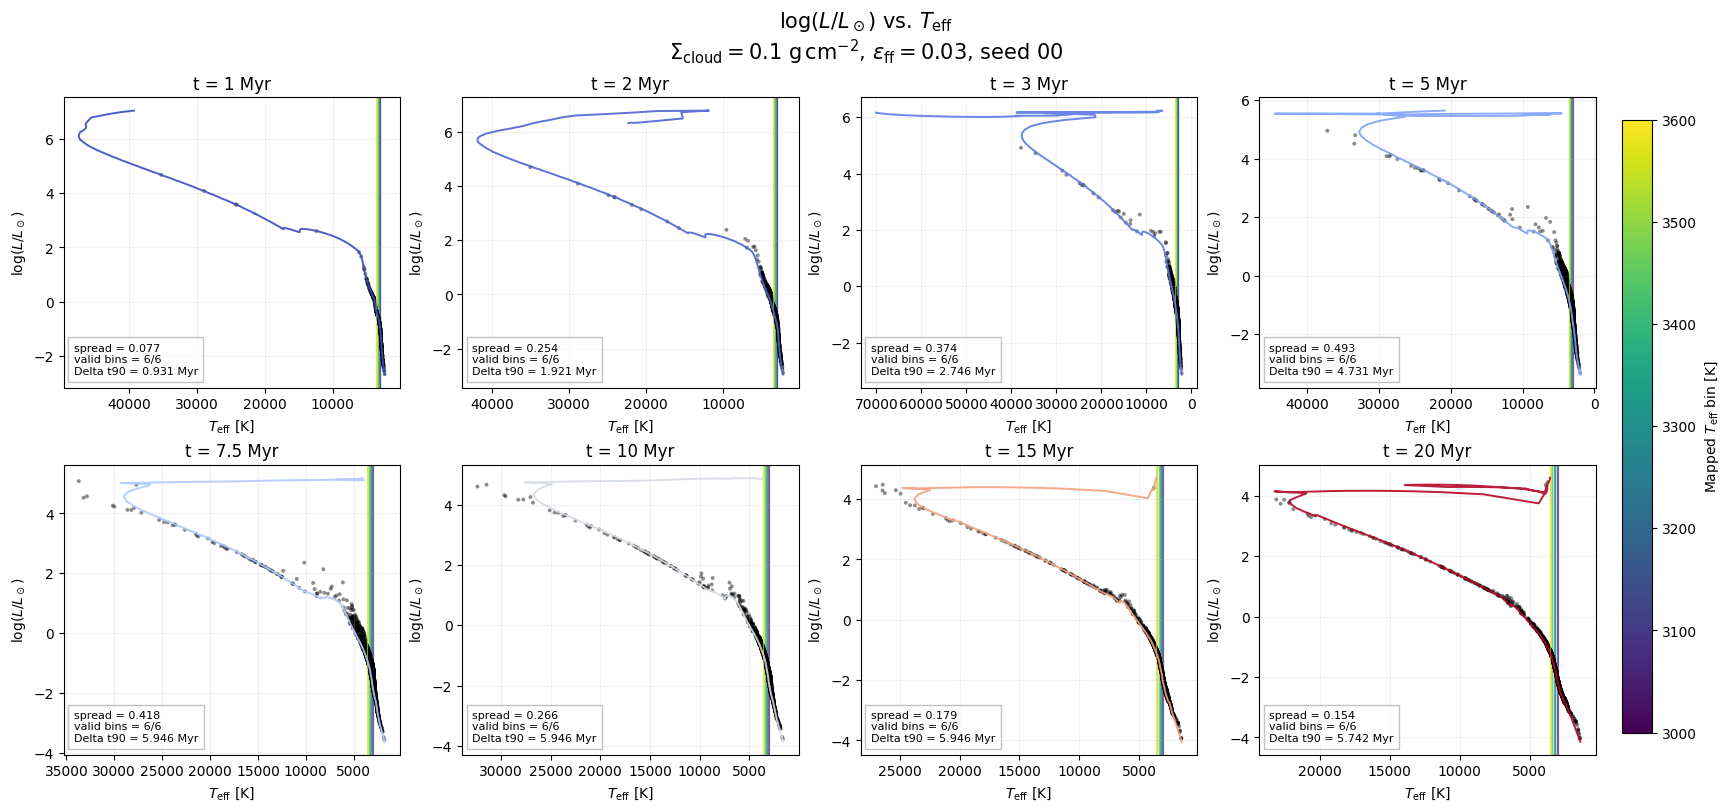

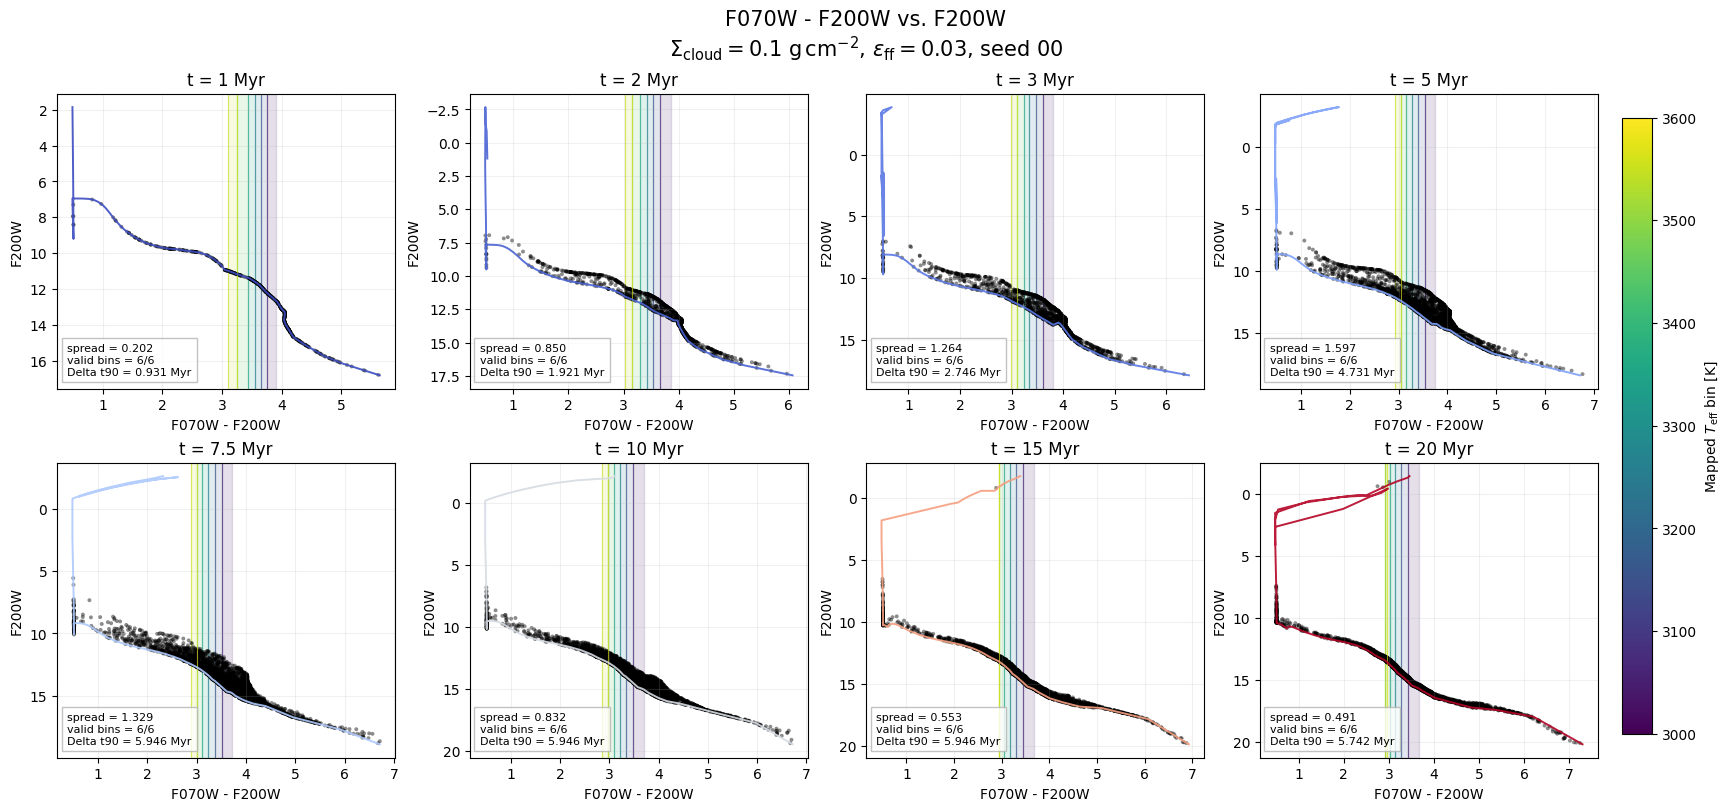

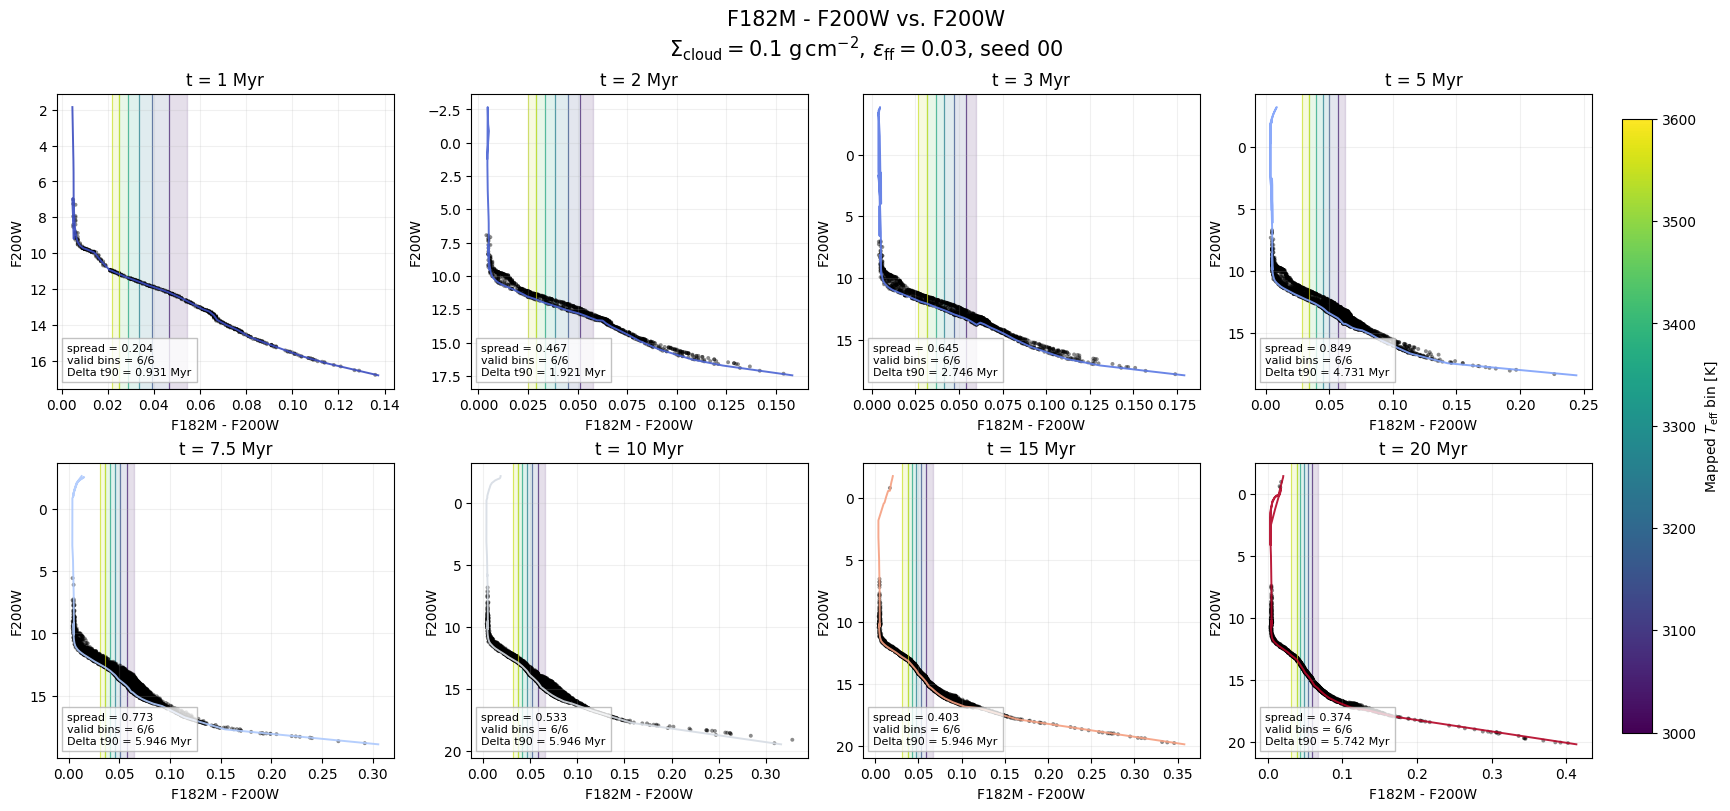

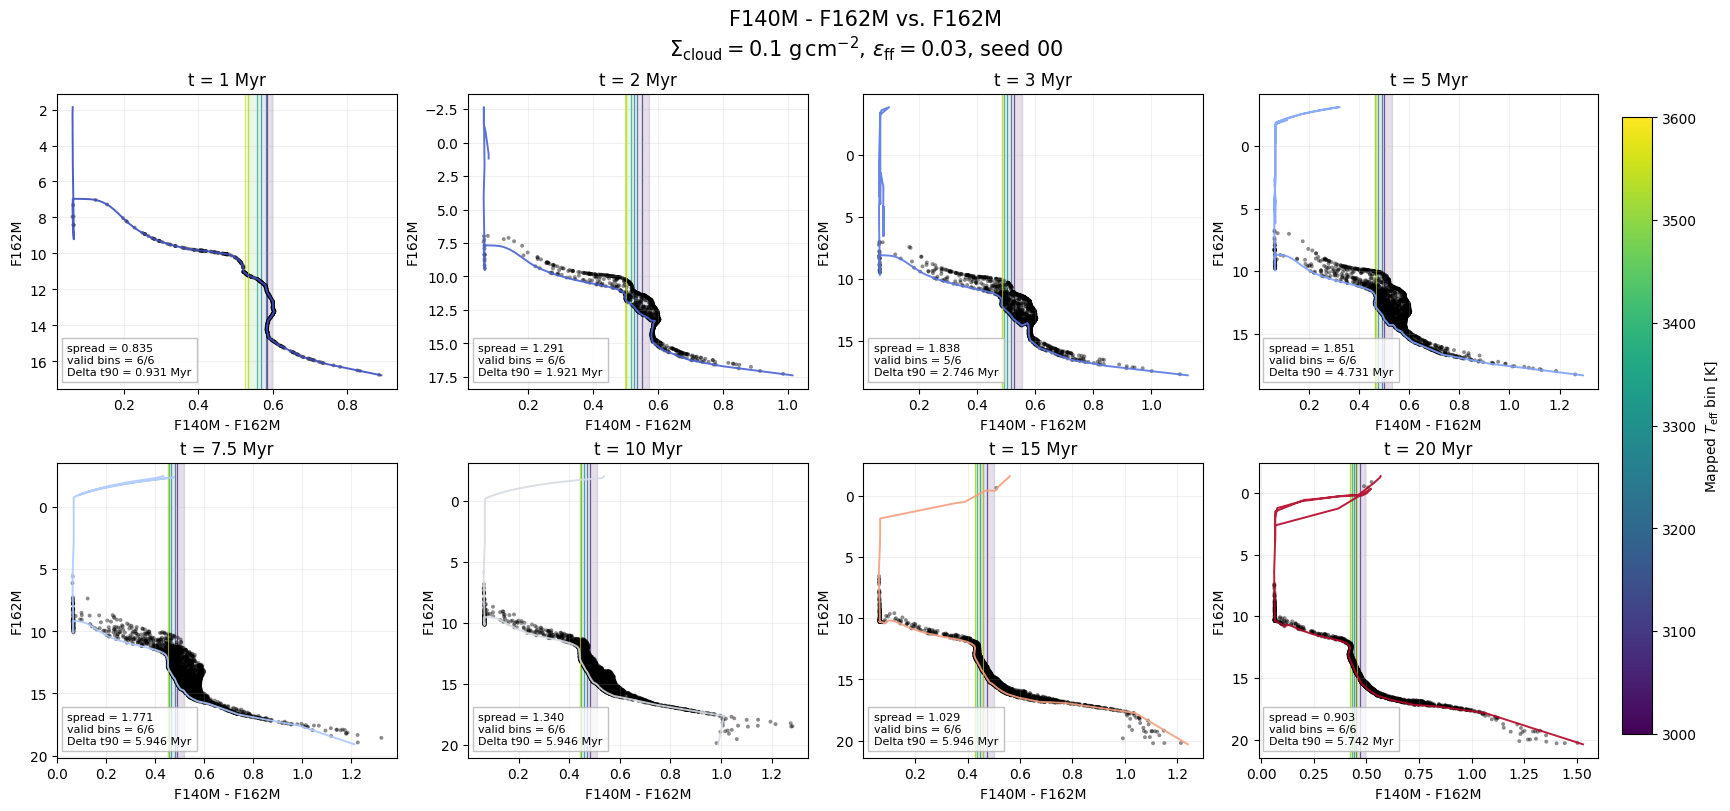

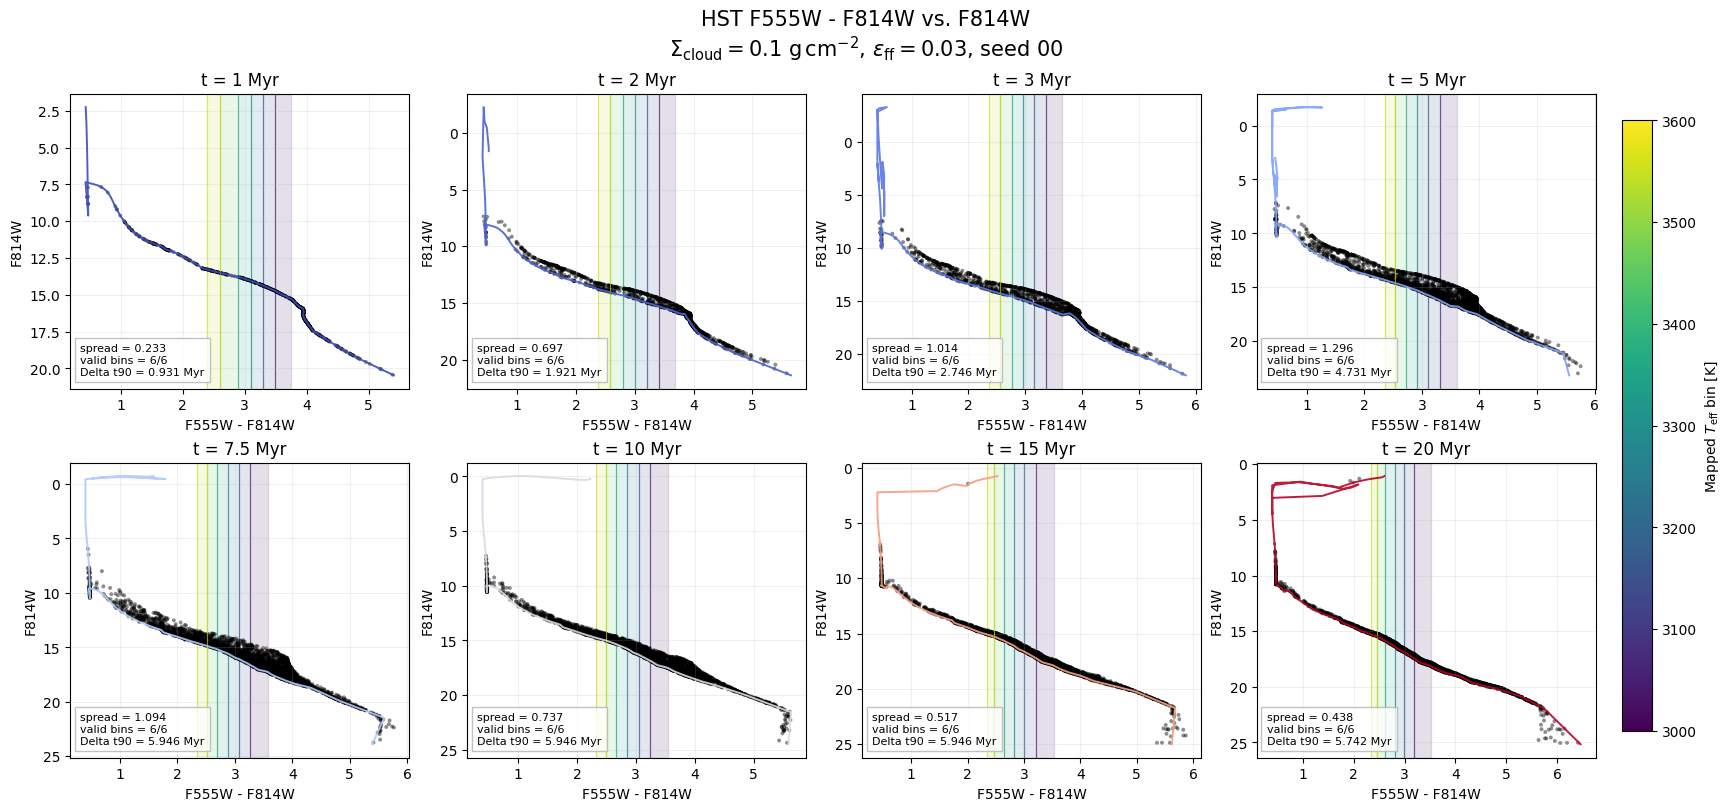

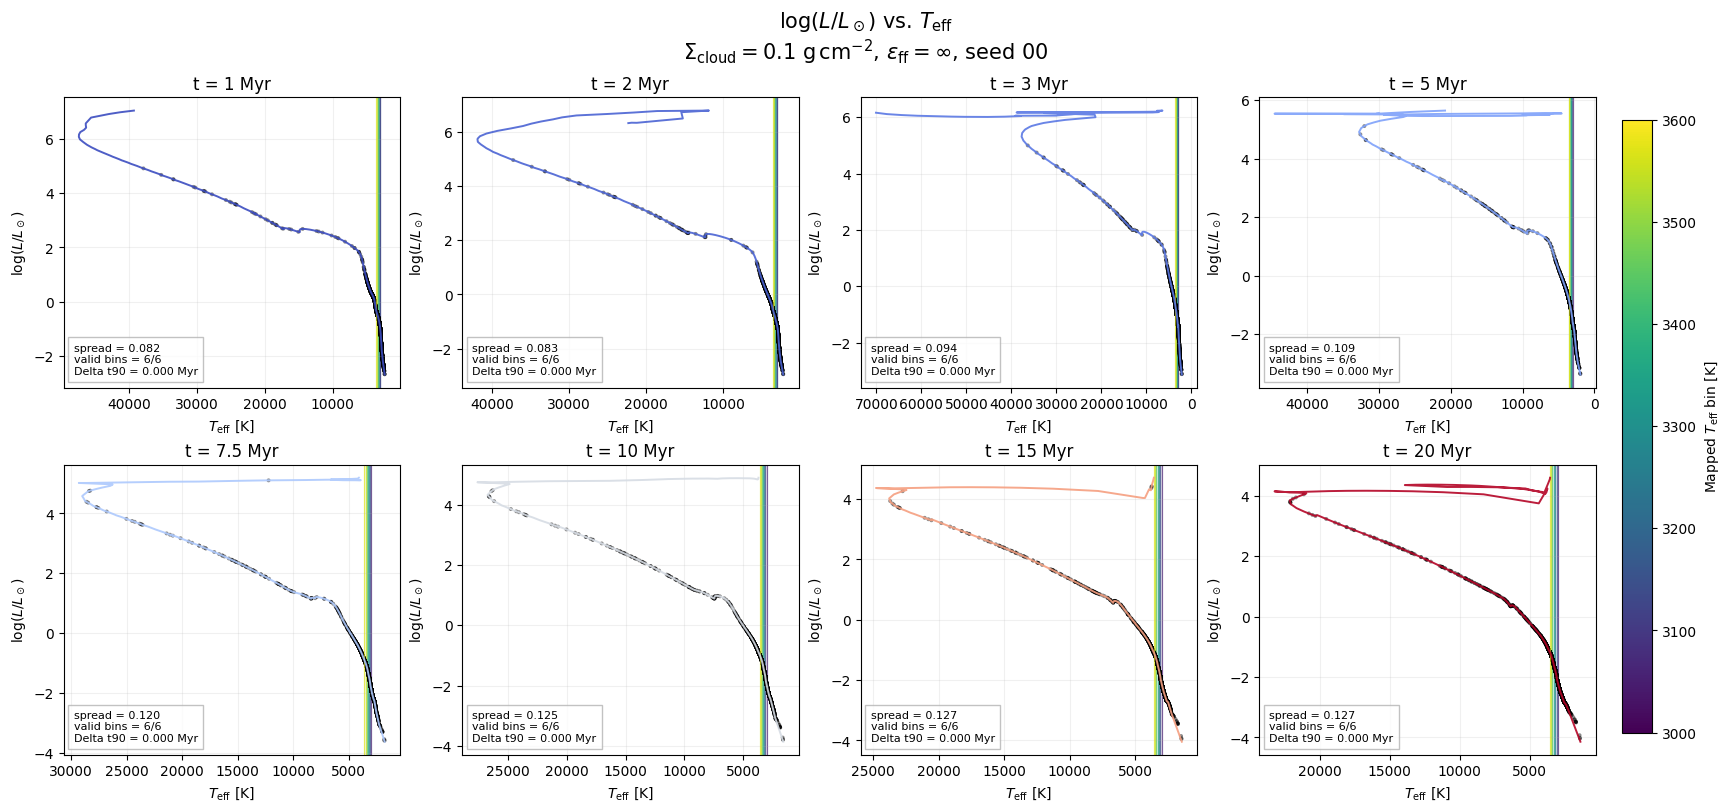

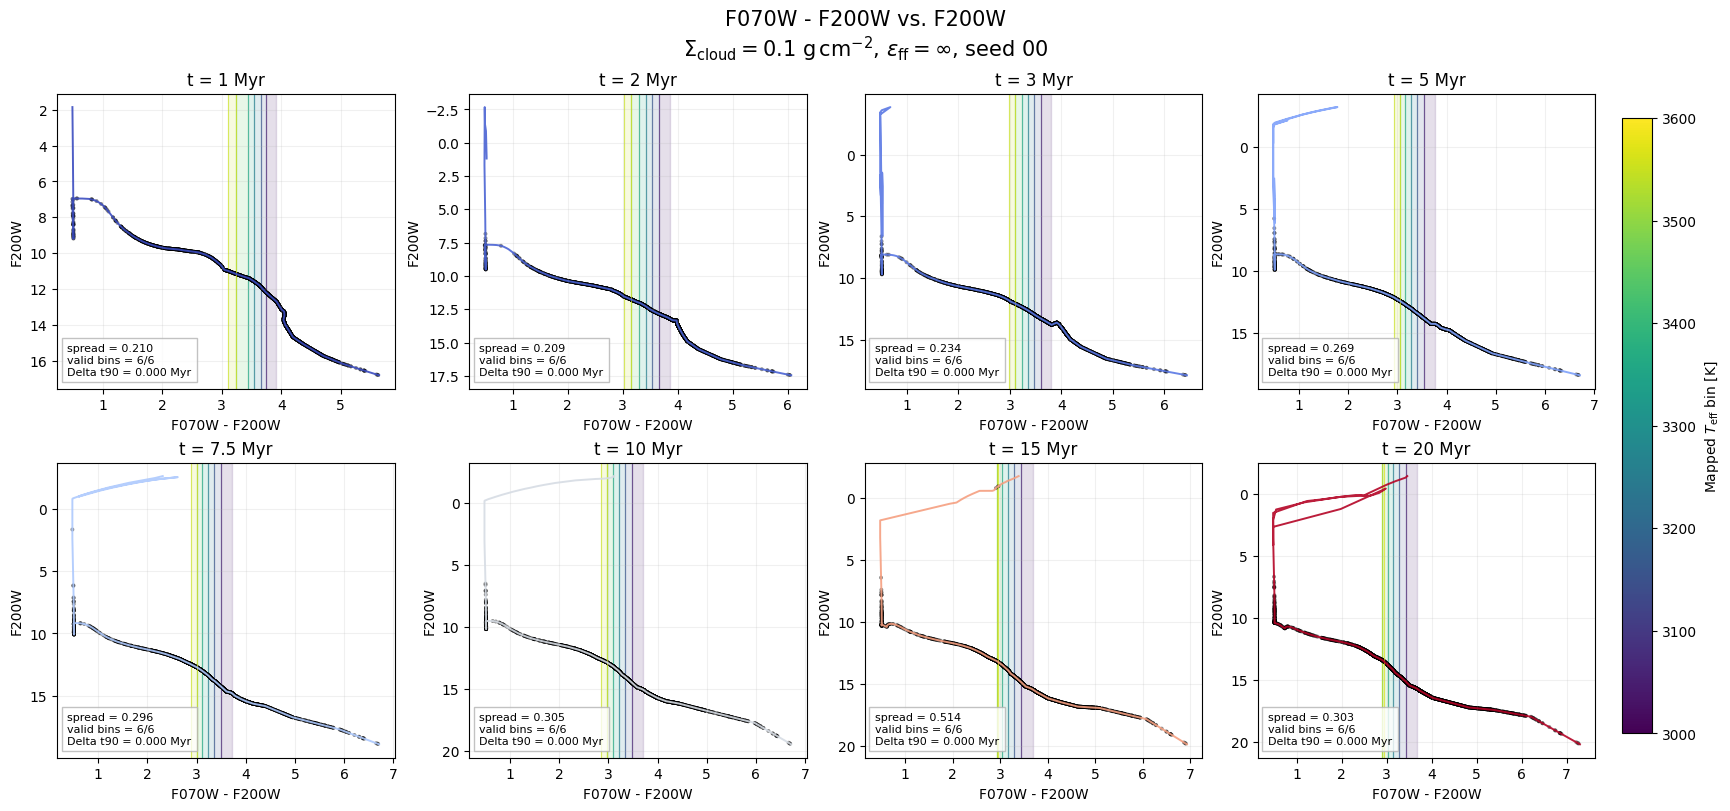

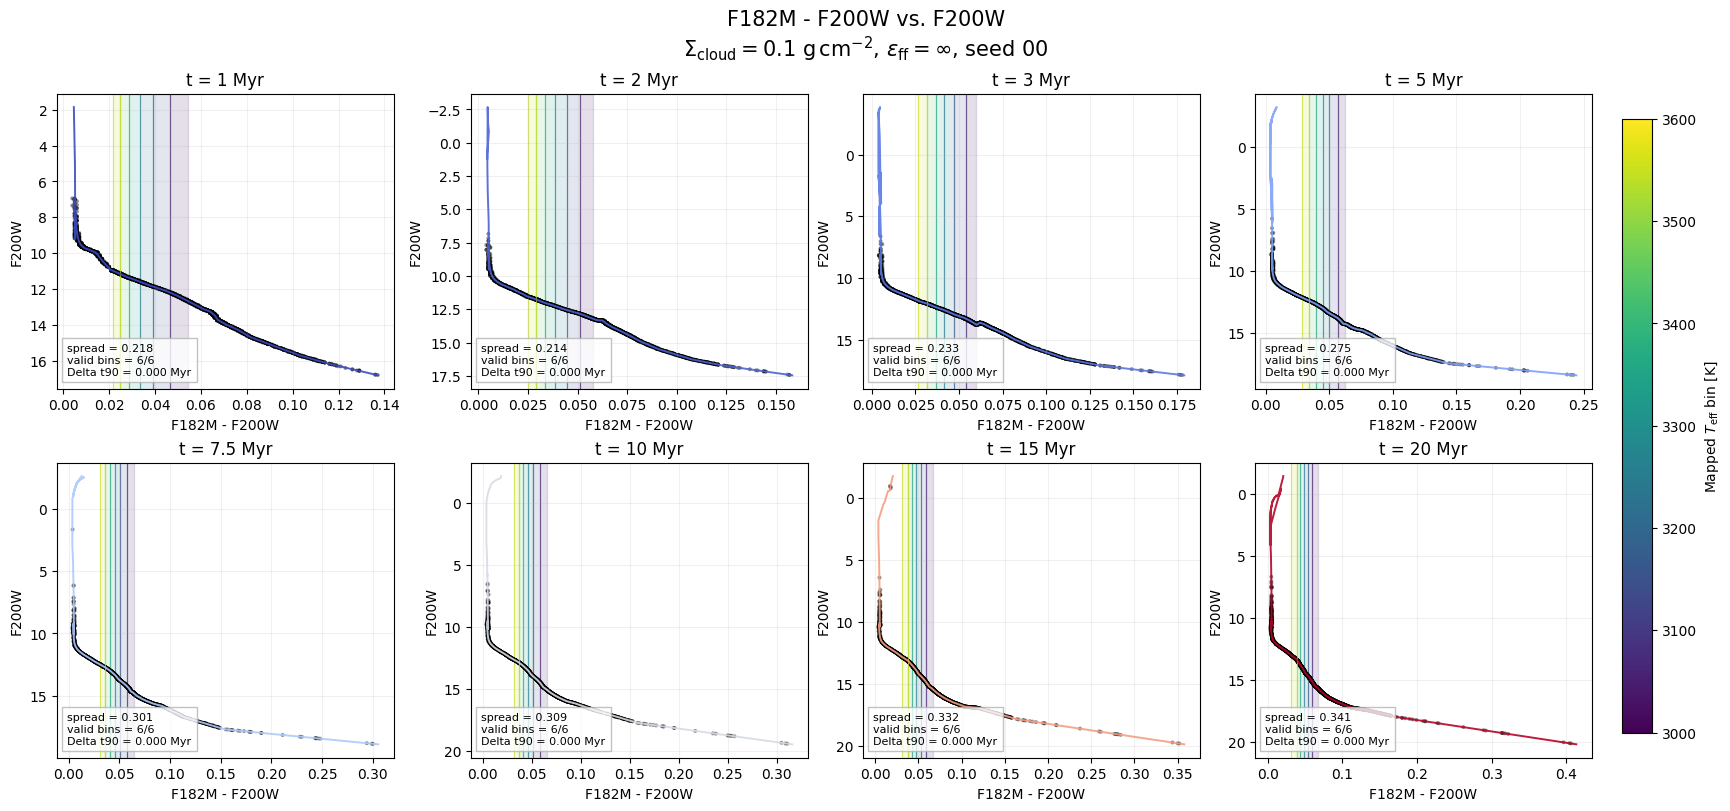

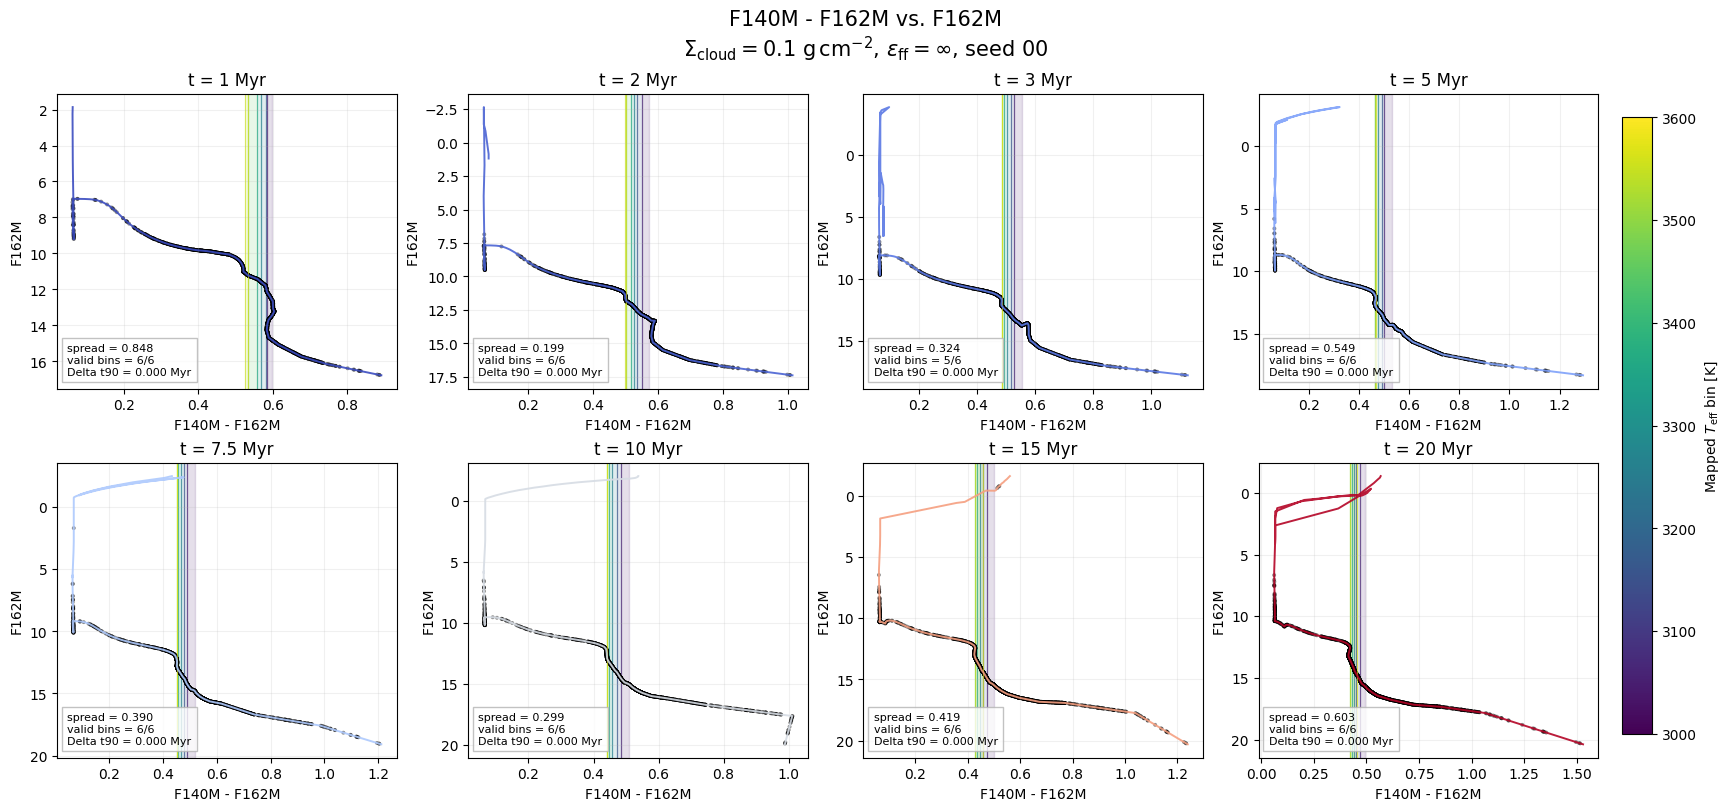

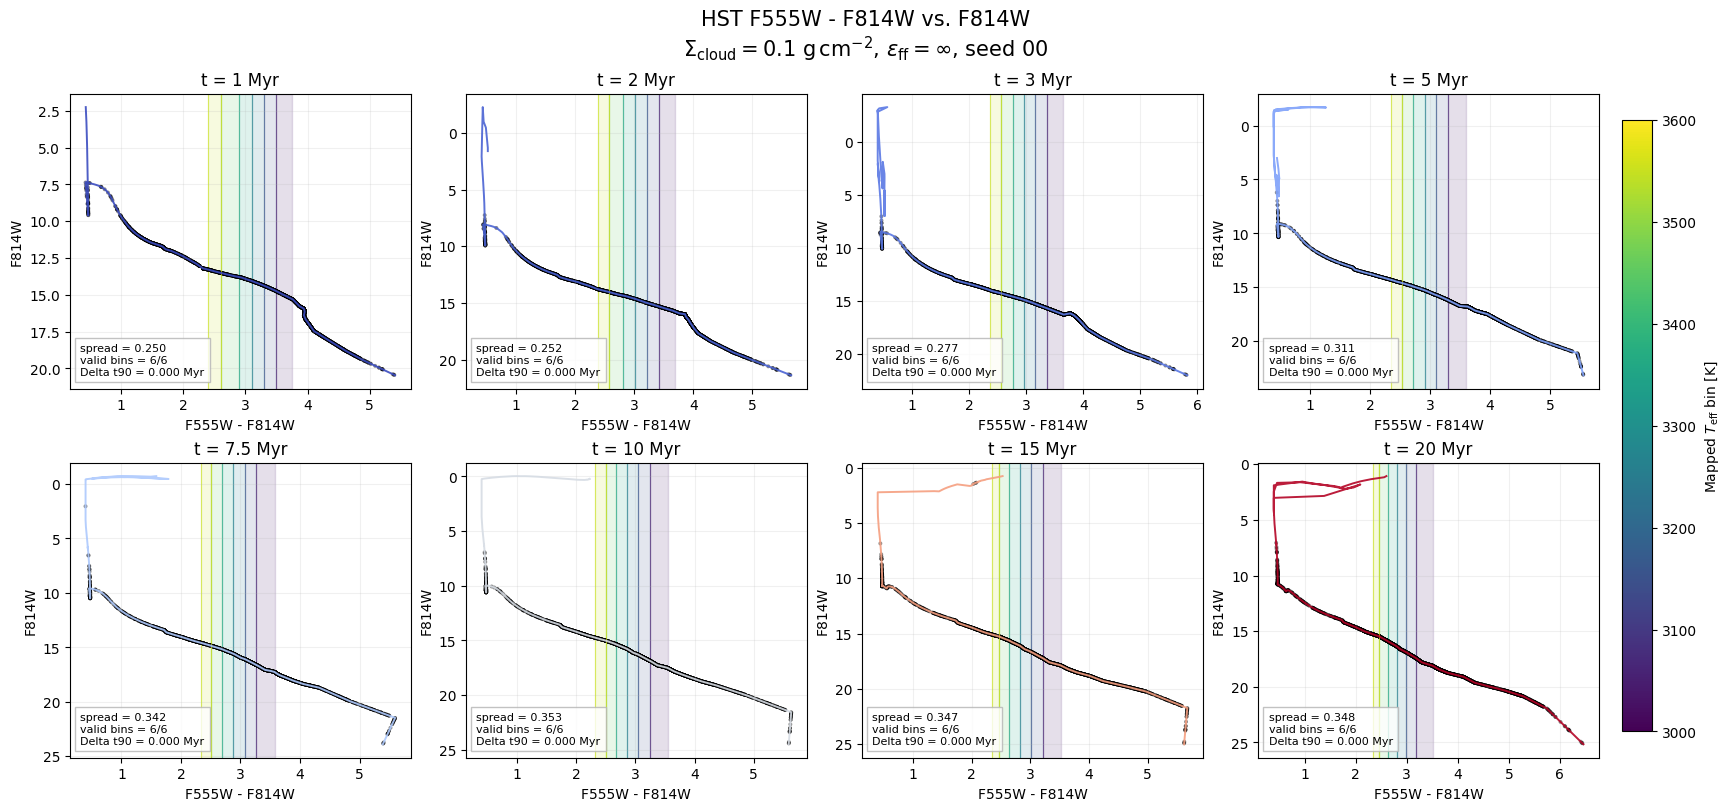

In [14]:
for case in [FINITE, INFINITE]:
    for diagram in DIAGRAMS:
        plot_time_evolution(case, diagram)

## Spread comparison: finite versus instantaneous

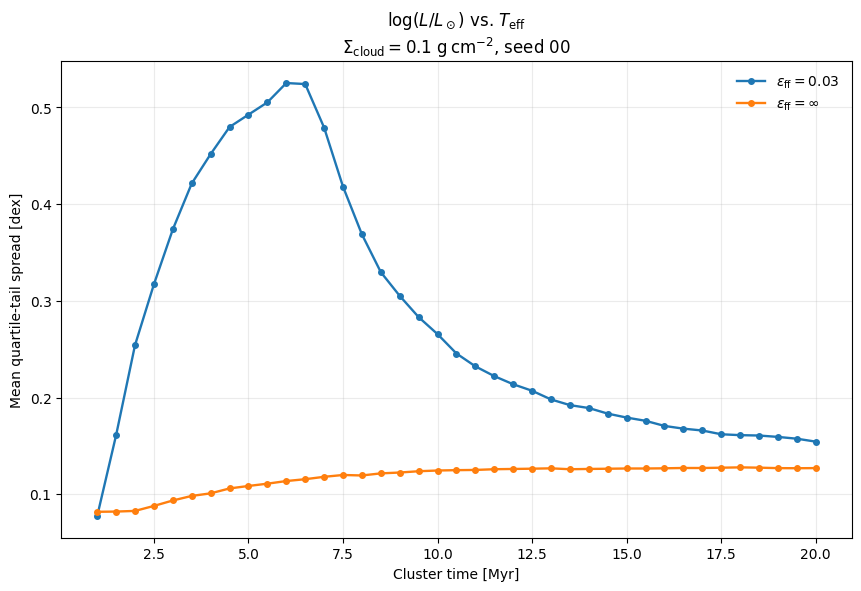

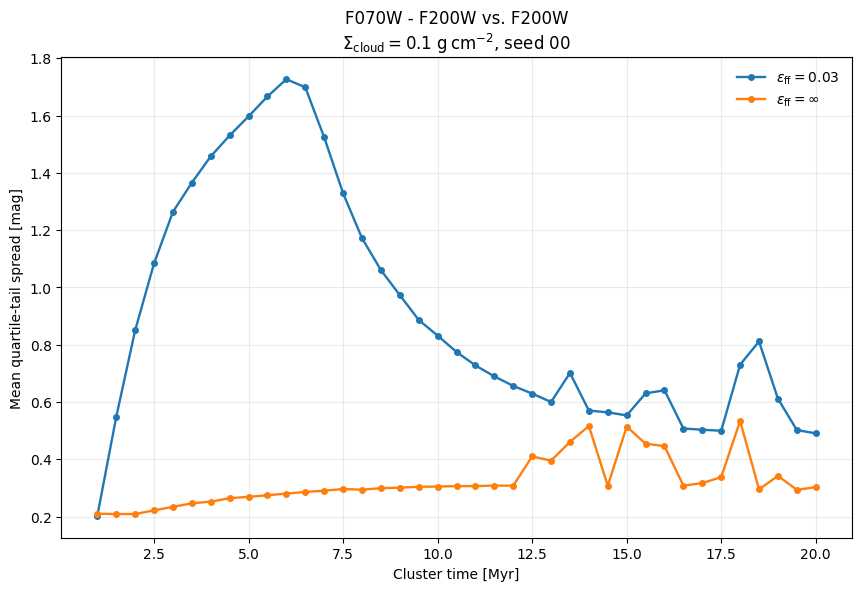

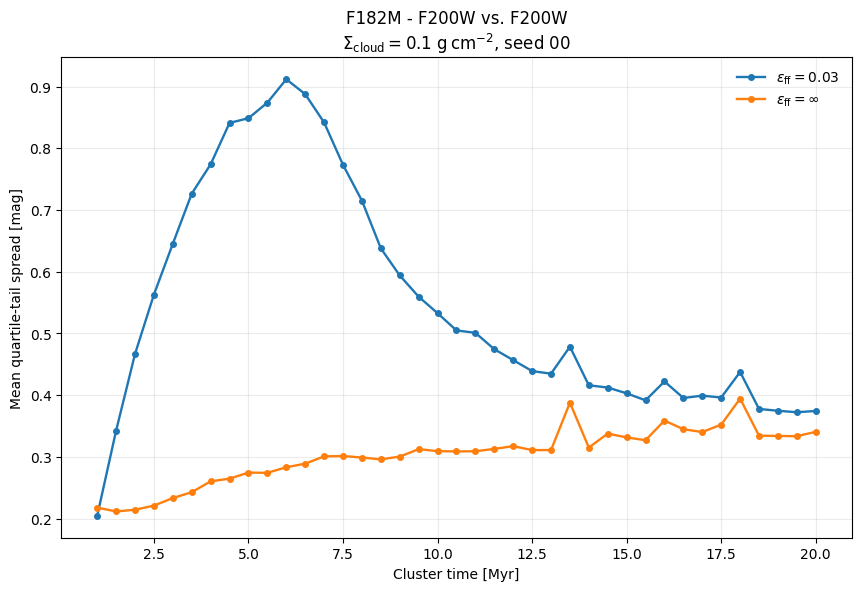

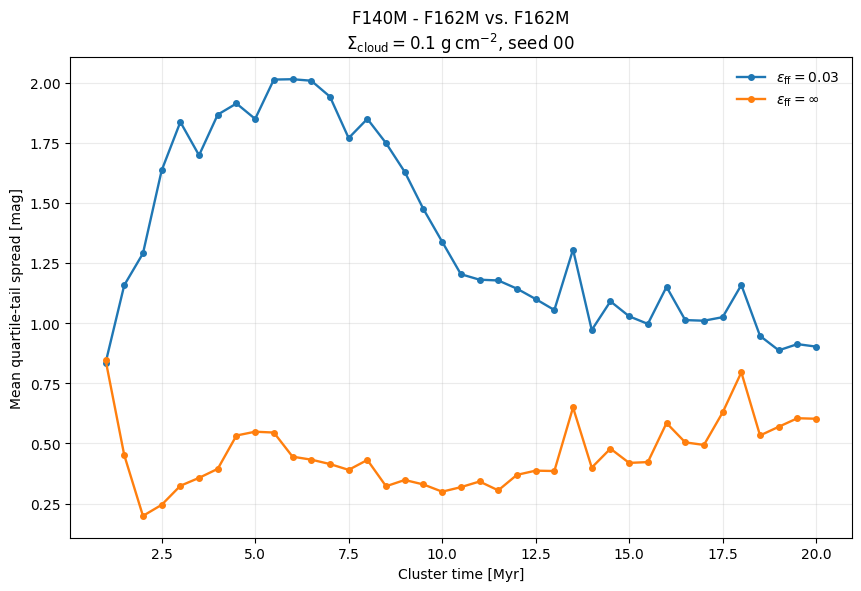

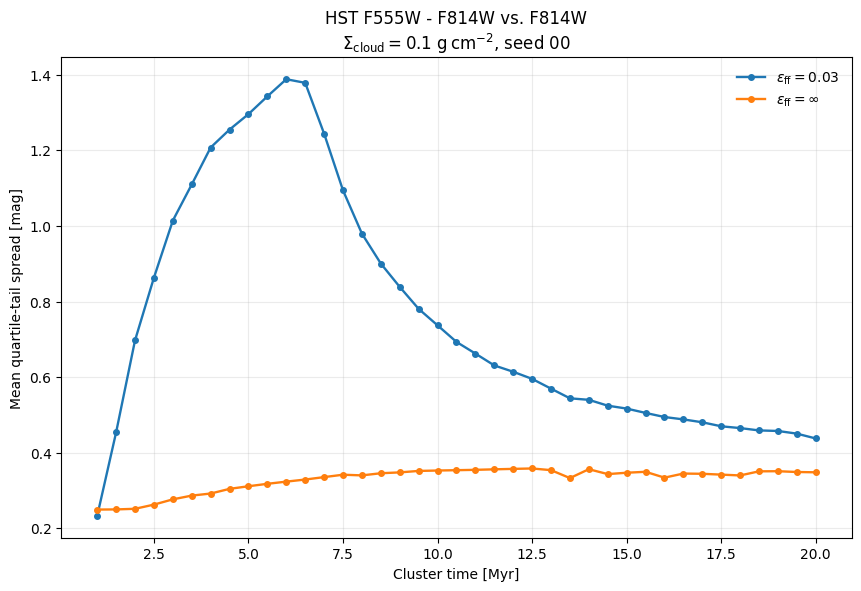

In [15]:
for diagram in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(8.5, 5.8), constrained_layout=True)
    for case in [FINITE, INFINITE]:
        sub = (df_metrics[(df_metrics['case'] == case)
                          & (df_metrics['diagram'] == diagram.key)]
               .sort_values('snapshot_time_myr'))
        ax.plot(sub['snapshot_time_myr'], sub['spread_metric'],
                marker='o', ms=4, lw=1.7, label=CASE_LABEL[case])
    unit = 'dex' if diagram.kind == 'hr' else 'mag'
    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel(f'Mean quartile-tail spread [{unit}]')
    ax.set_title(diagram.title + '\n'
                 + r'$\Sigma_{\rm cloud}=0.1\ {\rm g\,cm^{-2}}$, seed 00')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    finish_figure(fig, f'spread_comparison_{diagram.key}.png')

## Delta t90 validation plot

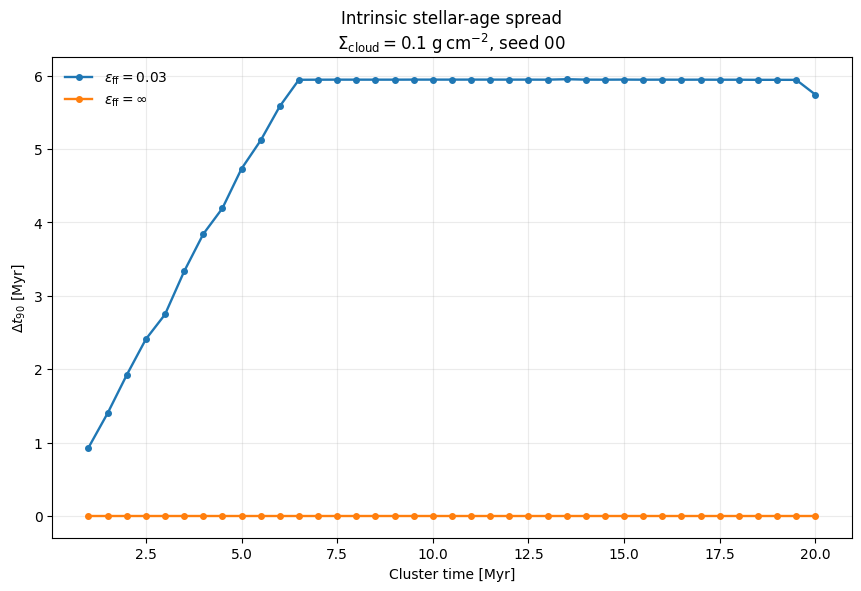

In [16]:
age_table = (df_metrics[['case', 'snapshot_time_myr',
                         'age_spread_p95_minus_p05_myr']]
             .drop_duplicates()
             .sort_values(['case', 'snapshot_time_myr']))
fig, ax = plt.subplots(figsize=(8.5, 5.8), constrained_layout=True)
for case in [FINITE, INFINITE]:
    sub = age_table[age_table['case'] == case]
    ax.plot(sub['snapshot_time_myr'], sub['age_spread_p95_minus_p05_myr'],
            marker='o', ms=4, lw=1.7, label=CASE_LABEL[case])
ax.set_xlabel('Cluster time [Myr]')
ax.set_ylabel(r'$\Delta t_{90}$ [Myr]')
ax.set_title('Intrinsic stellar-age spread\n'
             + r'$\Sigma_{\rm cloud}=0.1\ {\rm g\,cm^{-2}}$, seed 00')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
finish_figure(fig, 'age_spread_finite_vs_infinite.png')

## Metadata and output summary

In [17]:
metadata = {
    'simulation_path': str(SIMULATION_PATH),
    'sigma_cloud_g_cm2': 0.1,
    'finite_epsilon_ff': 0.03,
    'seed': '00',
    'finite_identifier_method': (
        'Exact converter ordering: current singles followed by current binary '
        'primaries; companion NAME values taken from Reader.read_binaries.'
    ),
    'instantaneous_method': (
        'Primordial snapshot-zero population plus all later SINGLE/BINARY '
        'entries in gradual.97 via get_primordial_binary_population; all '
        'formation times set to zero.'
    ),
    'analysis_times_myr': ANALYSIS_TIMES_MYR.tolist(),
    'isochrone_ages_myr': ISO_AGES_MYR.tolist(),
    'temperature_bin_edges_k': TEFF_BIN_EDGES_K.tolist(),
    'minimum_stars_per_bin': MIN_STARS_PER_BIN,
    'master_catalog_rows': int(len(df_master)),
    'master_single_systems': int((~df_master['is_multiple'].astype(bool)).sum()),
    'master_binary_systems': int(df_master['is_multiple'].astype(bool).sum()),
    'filters': FILTER_OBSMODES,
    'diagrams': [asdict(diagram) for diagram in DIAGRAMS],
}
(OUTPUT_DIR / 'analysis_metadata.json').write_text(json.dumps(metadata, indent=2))

print(f'Outputs: {OUTPUT_DIR.resolve()}')
print(f'Reusable analysis cache: {CACHE_DIR.resolve()}')
print(f'SPISEA isochrone cache: {ISO_CACHE_DIR.resolve()}')
print(f'Master catalog: {MASTER_PATH}')
print('Maximum instantaneous Delta t90:', max_instantaneous_dt90)

Outputs: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-04_cached-analysis-with-inf-freefall/seed00_finite_vs_infinite_outputs
Reusable analysis cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-04_cached-analysis-with-inf-freefall/analysis_cache
SPISEA isochrone cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-04_cached-analysis-with-inf-freefall/iso_cache
Master catalog: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-04_cached-analysis-with-inf-freefall/analysis_cache/instantaneous_master/master_catalog.csv
Maximum instantaneous Delta t90: 0.0
